# Retail Sales Analysis 😁

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('train.csv', parse_dates=['Date'])
features = pd.read_csv('features.csv.xls', parse_dates=['Date'])
stores = pd.read_csv('stores.csv.xls')
train_stores = pd.merge(left=train, right=stores, how='left', on='Store')
df = pd.merge(left=train_stores, right=features, how='left', on=['Store','Date','IsHoliday']) 

print("First few rows of the dataset:")
print(df.head())

First few rows of the dataset:
   Store  Dept       Date  Weekly_Sales  IsHoliday Type    Size  Temperature  \
0      1     1 2010-02-05      24924.50      False    A  151315        42.31   
1      1     1 2010-02-12      46039.49       True    A  151315        38.51   
2      1     1 2010-02-19      41595.55      False    A  151315        39.93   
3      1     1 2010-02-26      19403.54      False    A  151315        46.63   
4      1     1 2010-03-05      21827.90      False    A  151315        46.50   

   Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0       2.572        NaN        NaN        NaN        NaN        NaN   
1       2.548        NaN        NaN        NaN        NaN        NaN   
2       2.514        NaN        NaN        NaN        NaN        NaN   
3       2.561        NaN        NaN        NaN        NaN        NaN   
4       2.625        NaN        NaN        NaN        NaN        NaN   

          CPI  Unemployment  
0  211.096358         8.1

In [3]:
df.to_csv('data_sales.csv',index=False)
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667


In [4]:
print("\n Summary statistics of tha data:")
print(df.describe())


 Summary statistics of tha data:
               Store           Dept                           Date  \
count  421570.000000  421570.000000                         421570   
mean       22.200546      44.260317  2011-06-18 08:30:31.963375104   
min         1.000000       1.000000            2010-02-05 00:00:00   
25%        11.000000      18.000000            2010-10-08 00:00:00   
50%        22.000000      37.000000            2011-06-17 00:00:00   
75%        33.000000      74.000000            2012-02-24 00:00:00   
max        45.000000      99.000000            2012-10-26 00:00:00   
std        12.785297      30.492054                            NaN   

        Weekly_Sales           Size    Temperature     Fuel_Price  \
count  421570.000000  421570.000000  421570.000000  421570.000000   
mean    15981.258123  136727.915739      60.090059       3.361027   
min     -4988.940000   34875.000000      -2.060000       2.472000   
25%      2079.650000   93638.000000      46.680000       2.

In [5]:
print("\nData types and missing values:")
print(df.info())


Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float

In [6]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64

# Visual Representation of data

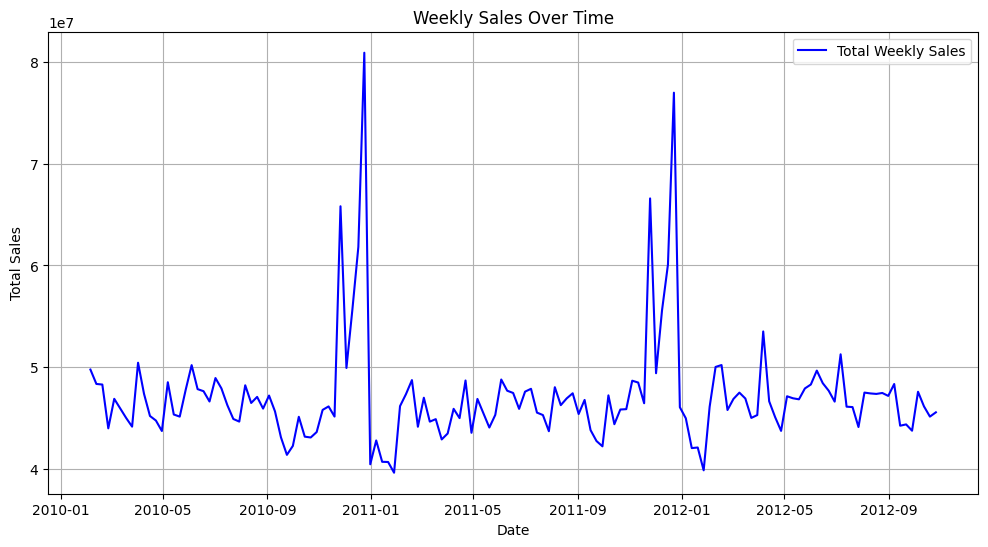

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
sales_over_time = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12, 6))
plt.plot(sales_over_time, label='Total Weekly Sales', color='blue')
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid()
plt.show()

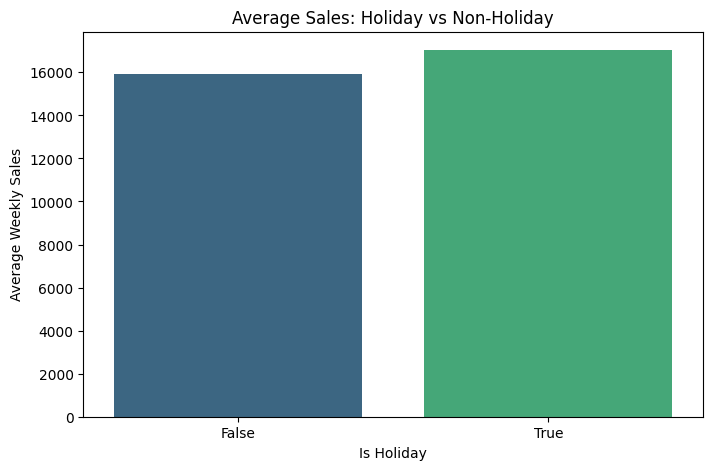

In [8]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=holiday_sales.index, y=holiday_sales.values, palette='viridis')
plt.title('Average Sales: Holiday vs Non-Holiday')
plt.xlabel('Is Holiday')
plt.ylabel('Average Weekly Sales')
plt.show()

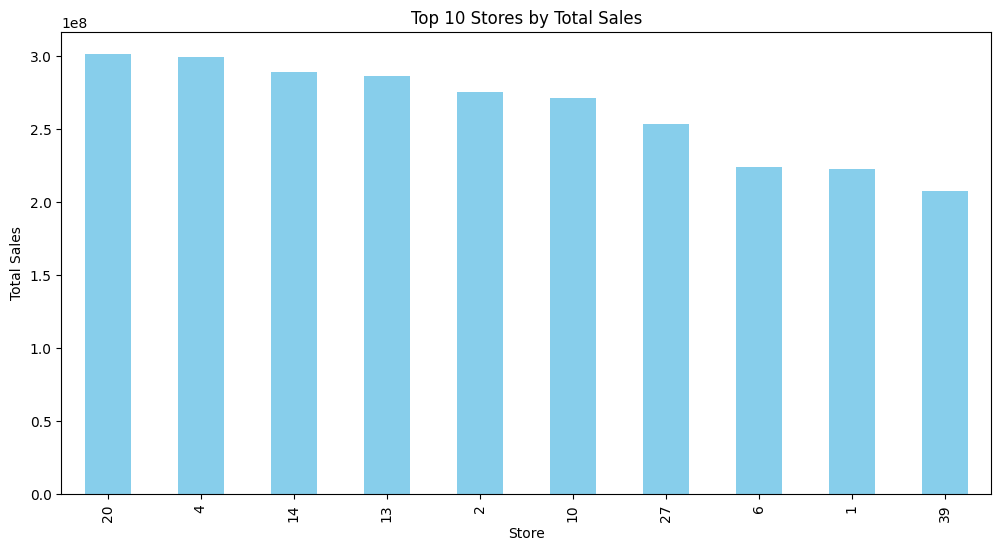

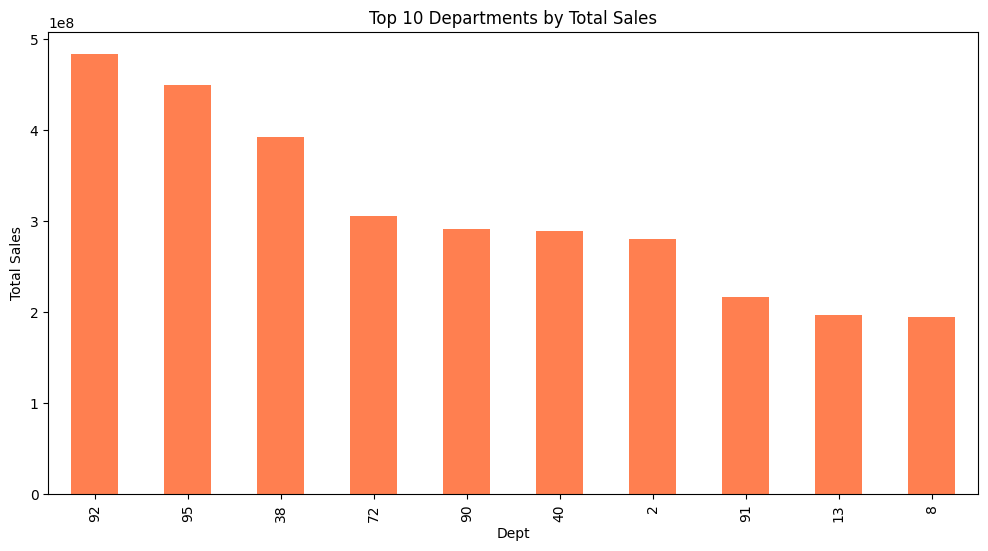

In [9]:
store_performance = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
dept_performance = df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
store_performance.head(10).plot(kind='bar', color='skyblue', title='Top 10 Stores by Total Sales')
plt.ylabel('Total Sales')
plt.show()

plt.figure(figsize=(12, 6))
dept_performance.head(10).plot(kind='bar', color='coral', title='Top 10 Departments by Total Sales')
plt.ylabel('Total Sales')
plt.show()

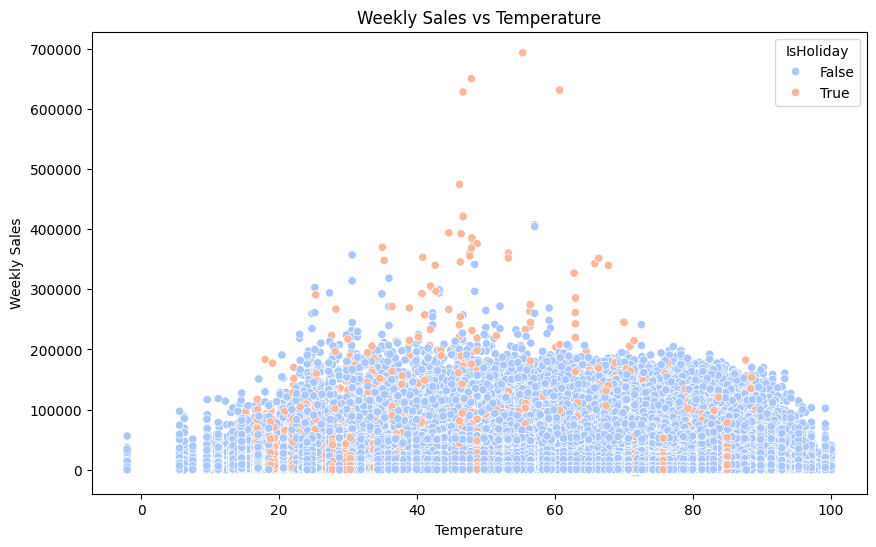

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, hue='IsHoliday', palette='coolwarm')
plt.title('Weekly Sales vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.show()

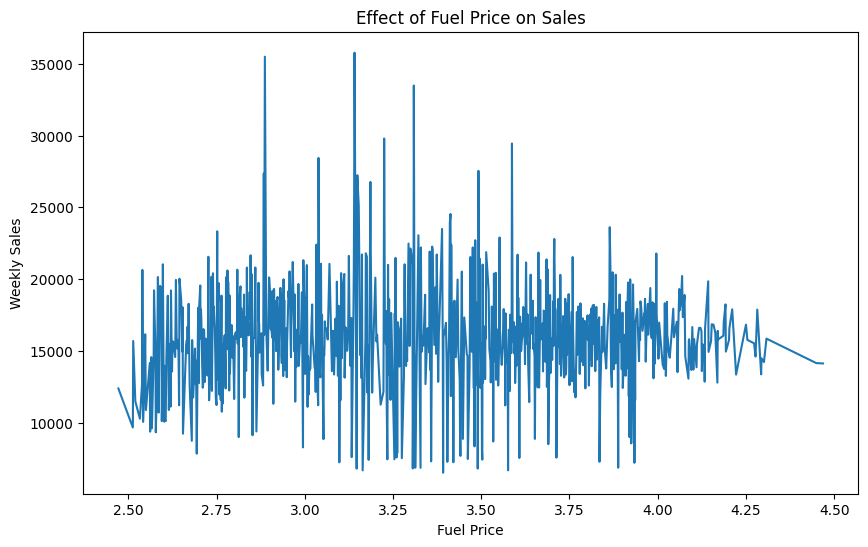

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Fuel_Price', y='Weekly_Sales', data=df, ci=None)
plt.title('Effect of Fuel Price on Sales')
plt.xlabel('Fuel Price')
plt.ylabel('Weekly Sales')
plt.show()

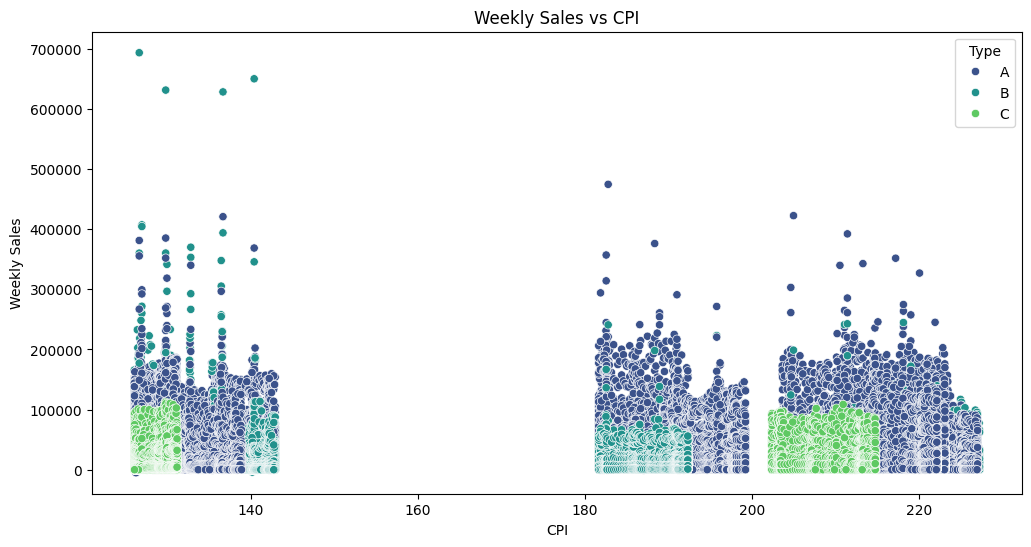

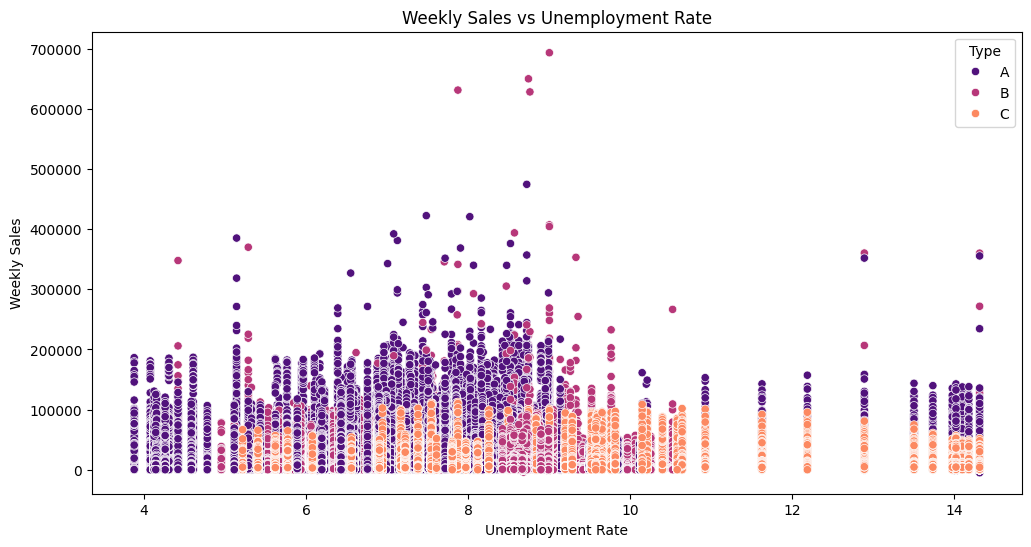

In [12]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='CPI', y='Weekly_Sales', data=df, hue='Type', palette='viridis')
plt.title('Weekly Sales vs CPI')
plt.xlabel('CPI')
plt.ylabel('Weekly Sales')
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df, hue='Type', palette='magma')
plt.title('Weekly Sales vs Unemployment Rate')
plt.xlabel('Unemployment Rate')
plt.ylabel('Weekly Sales')
plt.show()


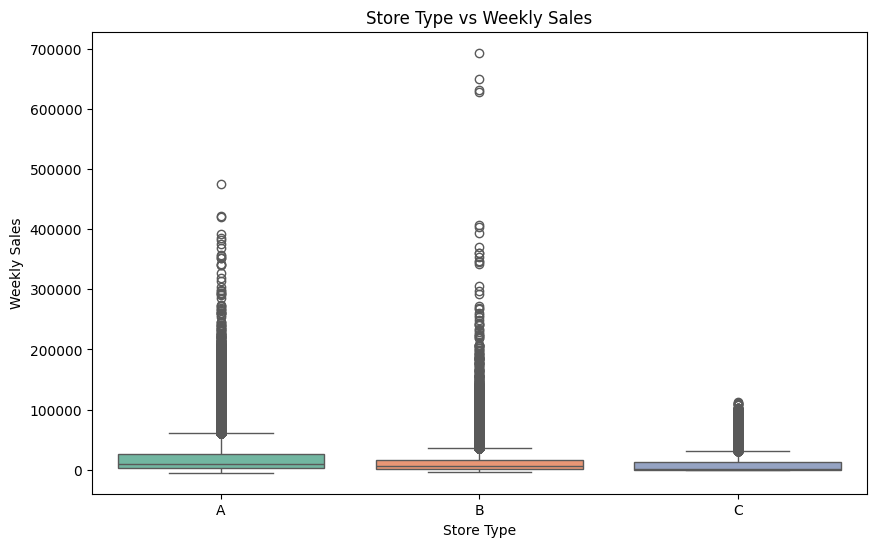

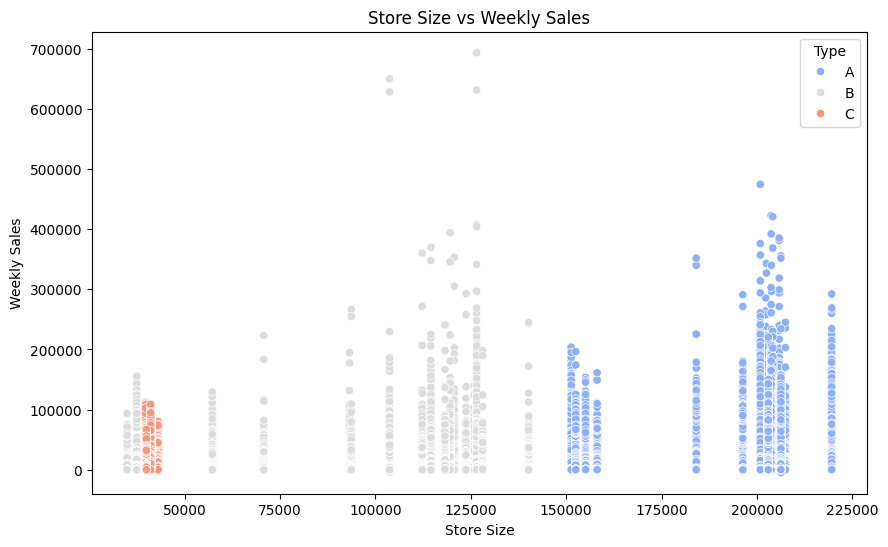

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Weekly_Sales', data=df, palette='Set2')
plt.title('Store Type vs Weekly Sales')
plt.xlabel('Store Type')
plt.ylabel('Weekly Sales')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size', y='Weekly_Sales', data=df, hue='Type', palette='coolwarm')
plt.title('Store Size vs Weekly Sales')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')
plt.show()

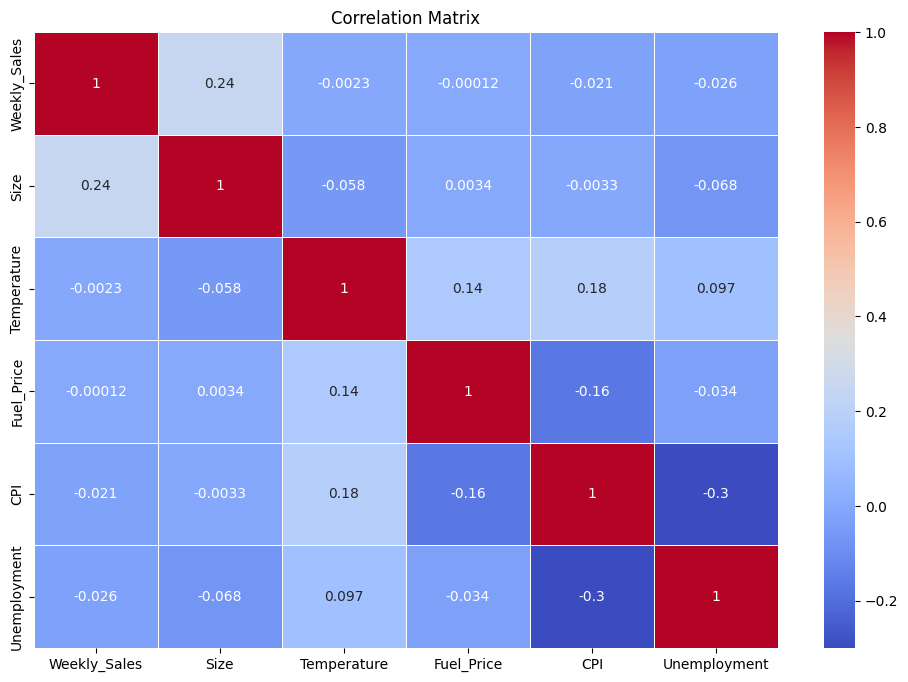

In [14]:
plt.figure(figsize=(12, 8))
corr = df[['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

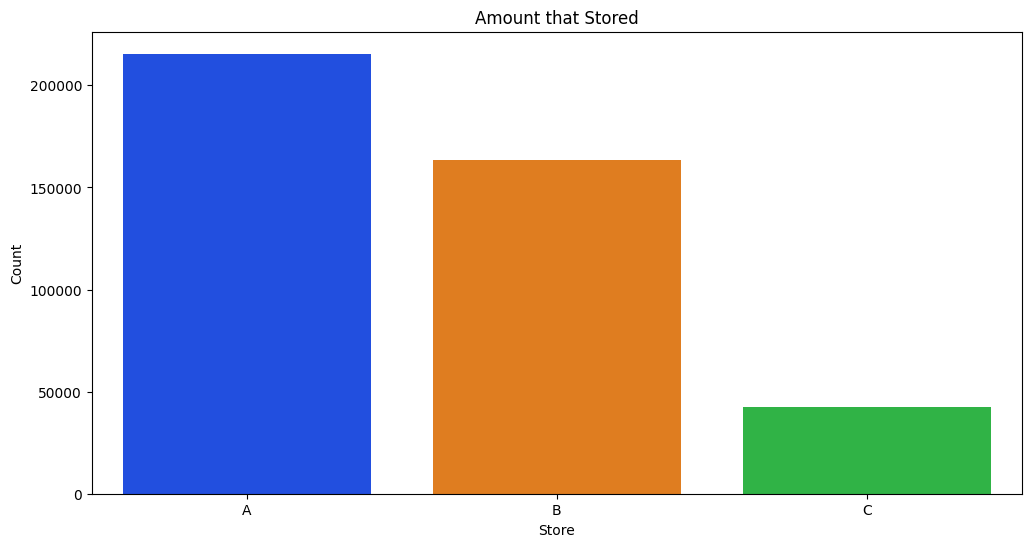

In [15]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Type', hue="Type",palette='bright')
plt.title('Amount that Stored')
plt.xlabel('Store')
plt.ylabel('Count')
# plt.xticks(rotation=45)
plt.show()

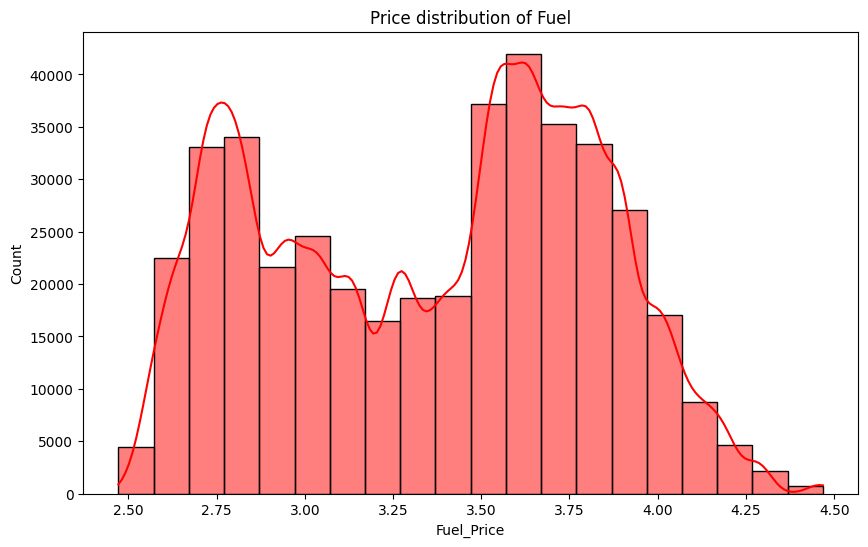

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Fuel_Price', bins=20, kde=True, color='red')
plt.title('Price distribution of Fuel')
plt.xlabel('Fuel_Price')
plt.ylabel('Count')
plt.show()

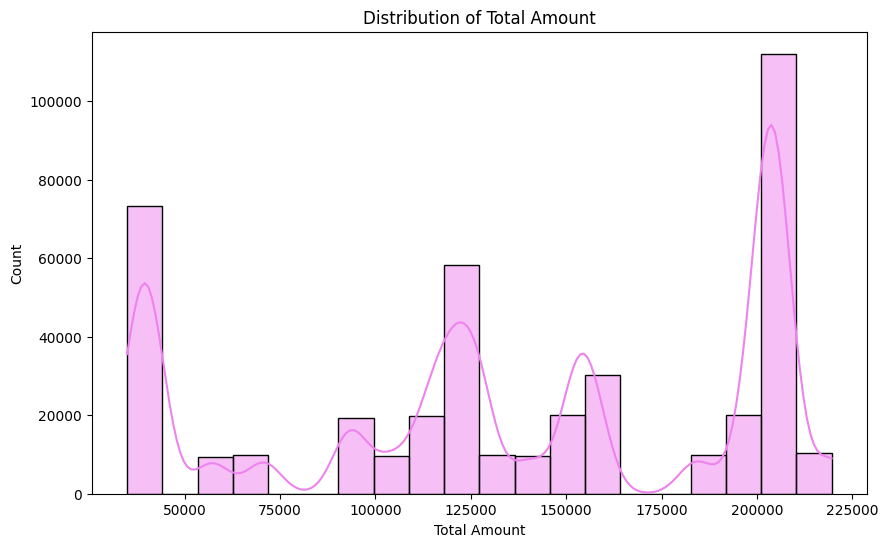

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Size', bins=20, kde=True, color='violet')
plt.title('Distribution of Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Count')
plt.show()

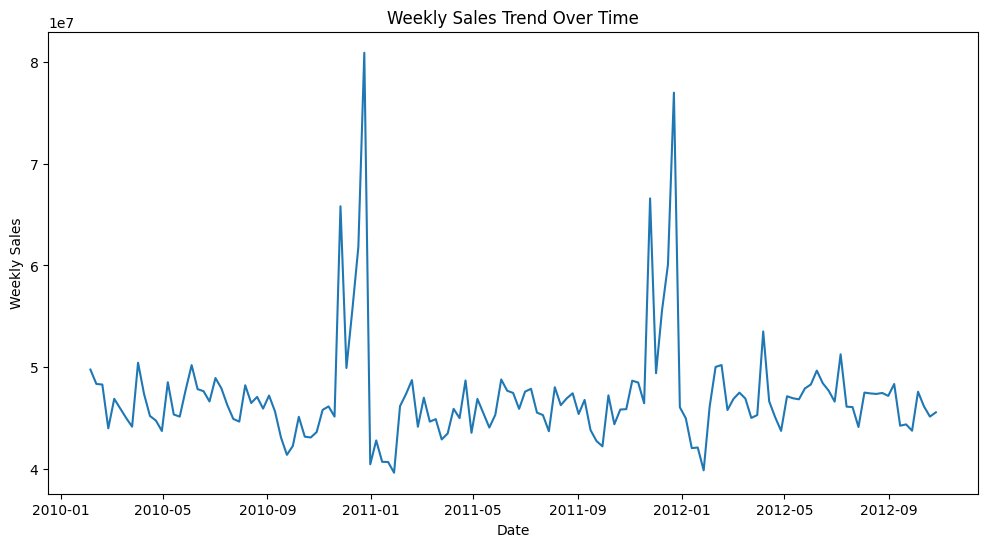

In [18]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Weekly_Sales', estimator='sum', ci=None)
plt.title('Weekly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()

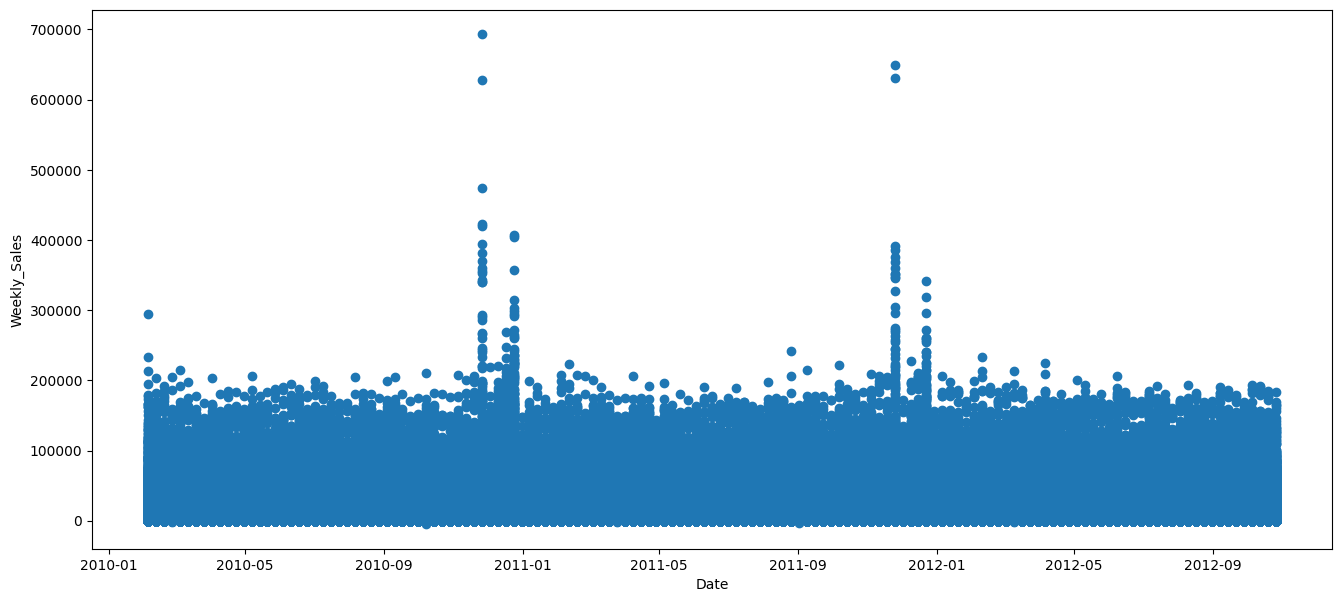

In [19]:
plt.figure(figsize=(16,7))
plt.scatter(x=df['Date'],y=df['Weekly_Sales'])
plt.xlabel('Date')
plt.ylabel('Weekly_Sales')
plt.show()

In [20]:
df.dropna()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
92,1,1,2011-11-11,18689.54,False,A,151315,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866,2011,11
93,1,1,2011-11-18,19050.66,False,A,151315,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866,2011,11
94,1,1,2011-11-25,20911.25,True,A,151315,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866,2011,11
95,1,1,2011-12-02,25293.49,False,A,151315,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866,2011,12
96,1,1,2011-12-09,33305.92,False,A,151315,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866,2011,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421561,45,98,2012-08-31,346.04,False,B,118221,75.09,3.867,23641.30,6.00,92.93,6988.31,3992.13,191.461281,8.684,2012,8
421562,45,98,2012-09-07,352.44,True,B,118221,75.70,3.911,11024.45,12.80,52.63,1854.77,2055.70,191.577676,8.684,2012,9
421564,45,98,2012-09-21,467.30,False,B,118221,65.32,4.038,8452.20,92.28,63.24,2376.38,8670.40,191.856704,8.684,2012,9
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9


## Univariate Analysis 
**before removing outliers**

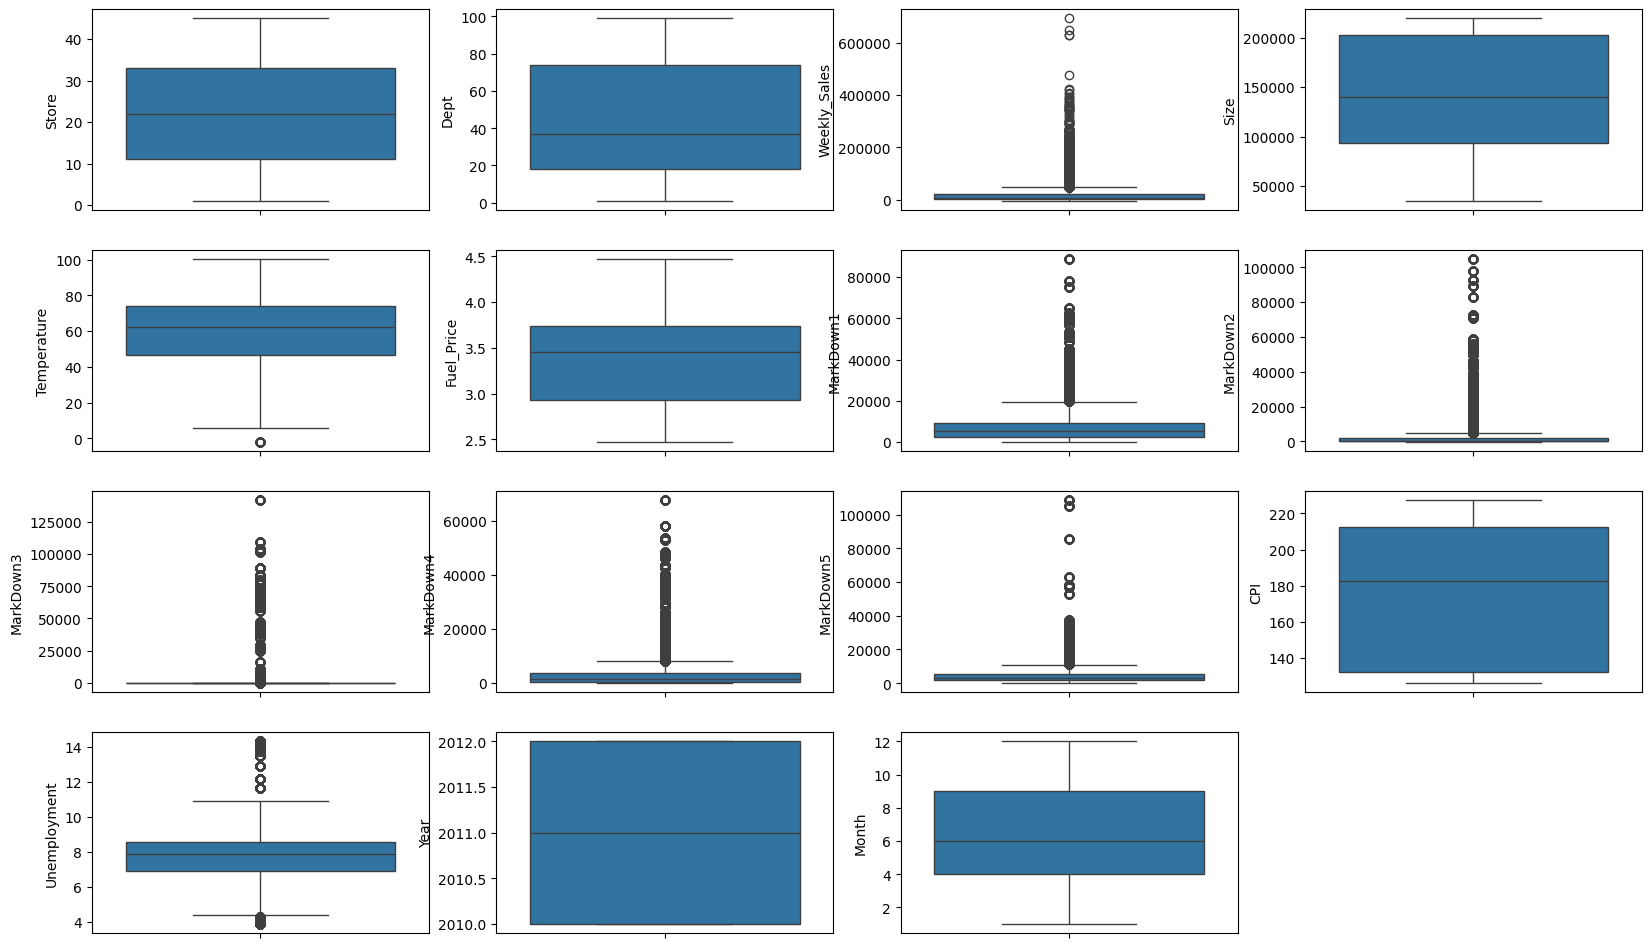

In [21]:
plt.figure(figsize=(20, 12))
for i, column in enumerate(df.select_dtypes(include='number'),1):
    plt.subplot(4,4,i)
    sns.boxplot(df[column])

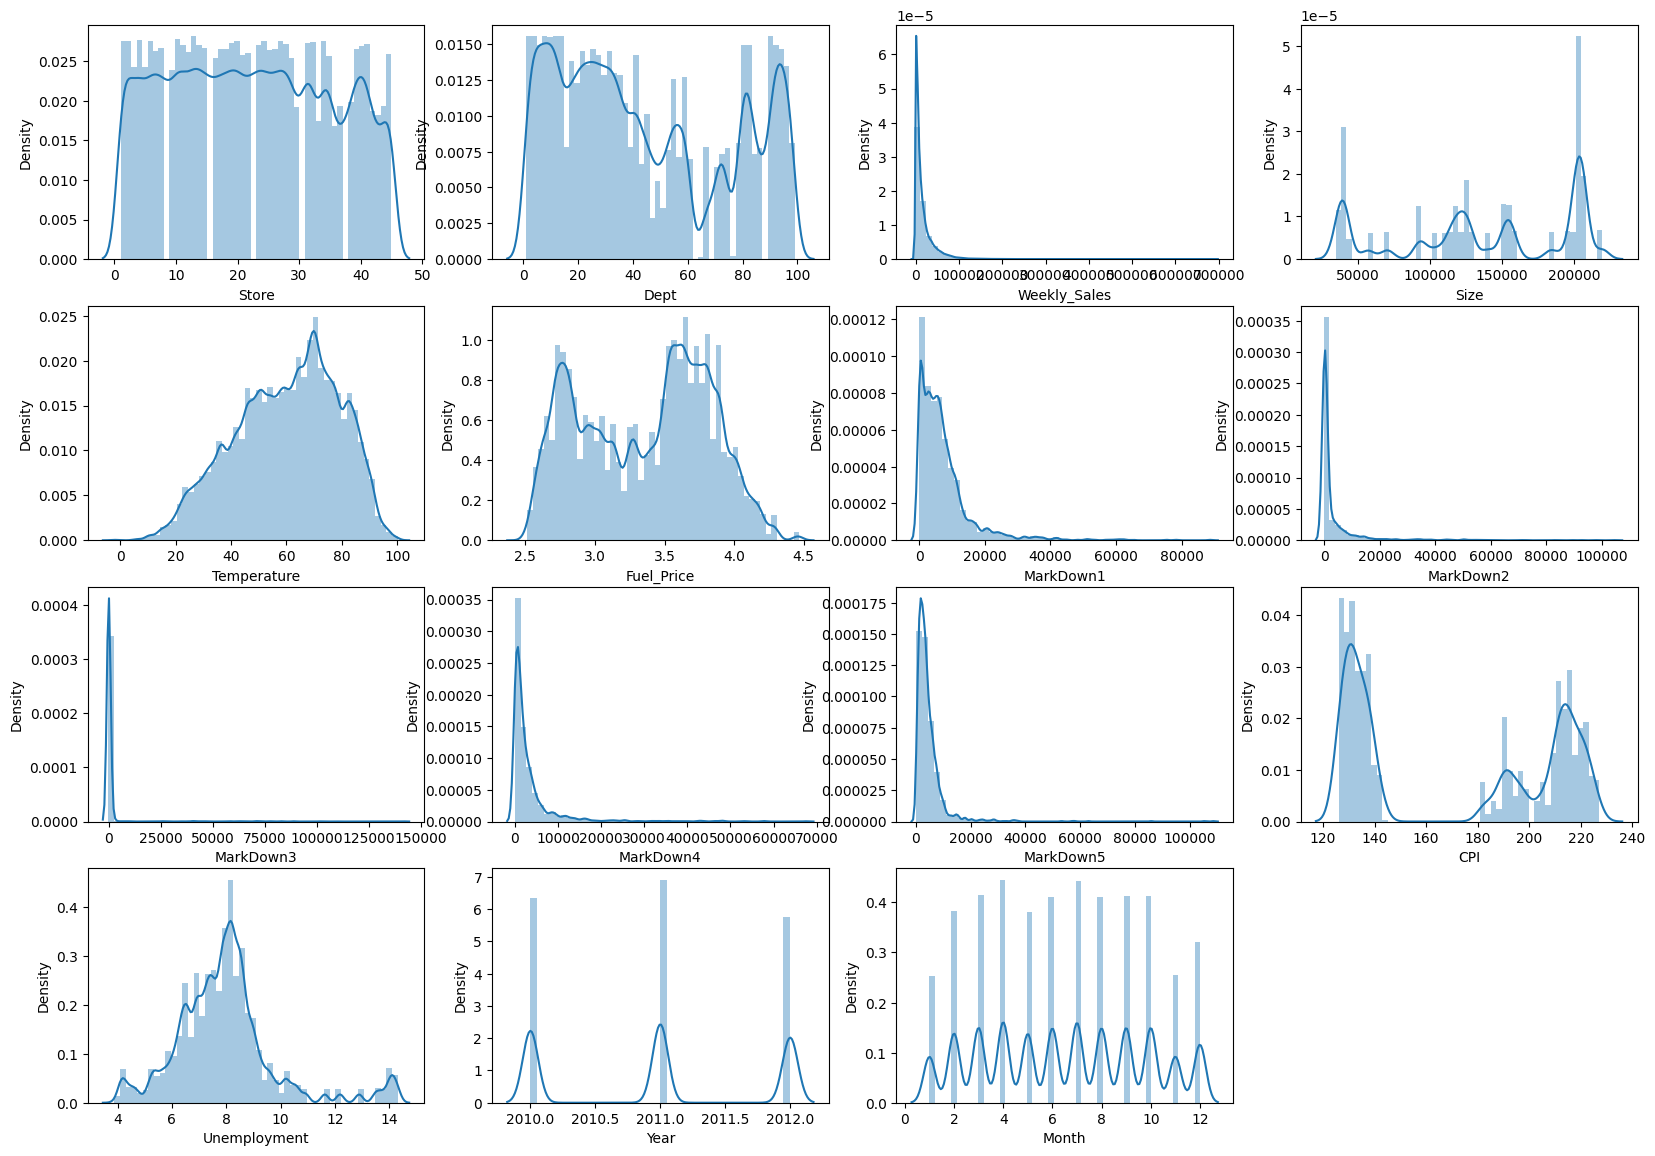

In [22]:
plt.figure(figsize=(20, 14))
for i, column in enumerate(df.select_dtypes(include='number'),1):
    plt.subplot(4,4,i)
    sns.distplot(df[column])

In [23]:
for i in df.select_dtypes(include='number'):
    skewness=df[i].skew()
    print("The skewness of",i,"is",skewness)

The skewness of Store is 0.07776250174537733
The skewness of Dept is 0.3582231934713366
The skewness of Weekly_Sales is 3.2620081854656657
The skewness of Size is -0.3258497664635348
The skewness of Temperature is -0.3214041519699762
The skewness of Fuel_Price is -0.10490149562840598
The skewness of MarkDown1 is 3.34184468638083
The skewness of MarkDown2 is 5.441261195703792
The skewness of MarkDown3 is 8.399453017706929
The skewness of MarkDown4 is 4.847500037212776
The skewness of MarkDown5 is 8.169909544116662
The skewness of CPI is 0.08521928473260011
The skewness of Unemployment is 1.1837425684974319
The skewness of Year is 0.05623644391430117
The skewness of Month is 0.04078624154148521


# Checking for outliers

In [24]:
df.shape

(421570, 18)

In [25]:
df.dtypes

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
Type                    object
Size                     int64
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Year                     int32
Month                    int32
dtype: object

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.describe(include='object')

,Type
count,421570
unique,3
top,A
freq,215478


In [28]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,136727.915739,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,2010.968591,6.449510
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,34875.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,2010.000000,1.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,93638.000000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,2010.000000,4.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,140167.000000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,2011.000000,6.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,202505.000000,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,2012.000000,9.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,2012.000000,12.000000
std,12.785297,30.492054,NaN,22711.183519,60980.583328,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,0.796876,3.243217


In [29]:
df=df.drop('Date',axis=1)

In [30]:
df.isnull().sum()

Store                0
Dept                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Year                 0
Month                0
dtype: int64

In [31]:
df['MarkDown1'].dropna()

92        10382.90
93         6074.12
94          410.31
95         5629.51
96         4640.65
            ...   
421565     4556.61
421566     5046.74
421567     1956.28
421568     2004.02
421569     4018.91
Name: MarkDown1, Length: 150681, dtype: float64

In [32]:
df.isnull().sum()

Store                0
Dept                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Year                 0
Month                0
dtype: int64

In [33]:
df['MarkDown1'].skew()

np.float64(3.34184468638083)

In [34]:
df['MarkDown2'].skew()

np.float64(5.441261195703792)

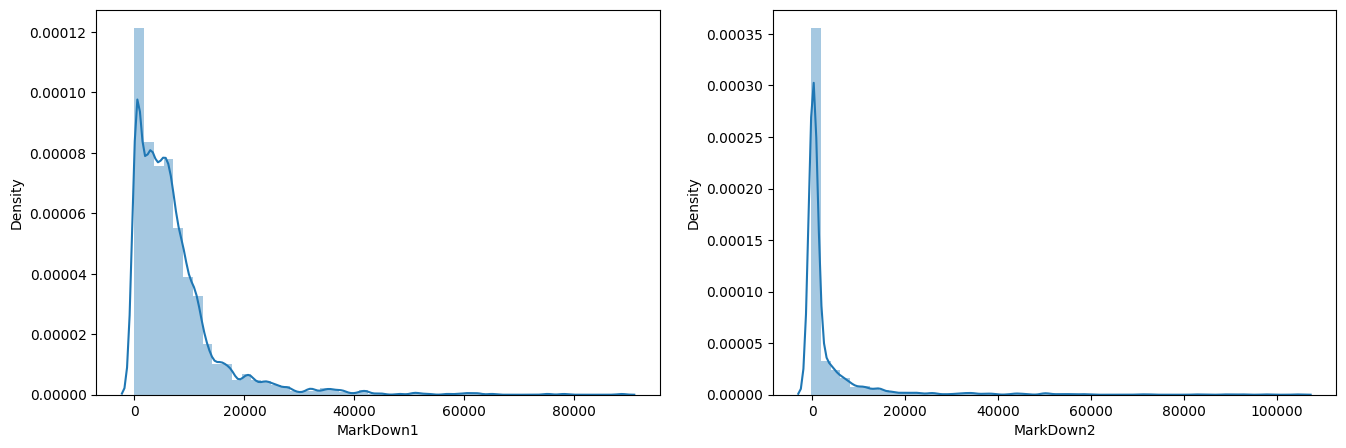

In [35]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['MarkDown1'])

plt.subplot(1,2,2)
sns.distplot(df['MarkDown2'])

plt.show()

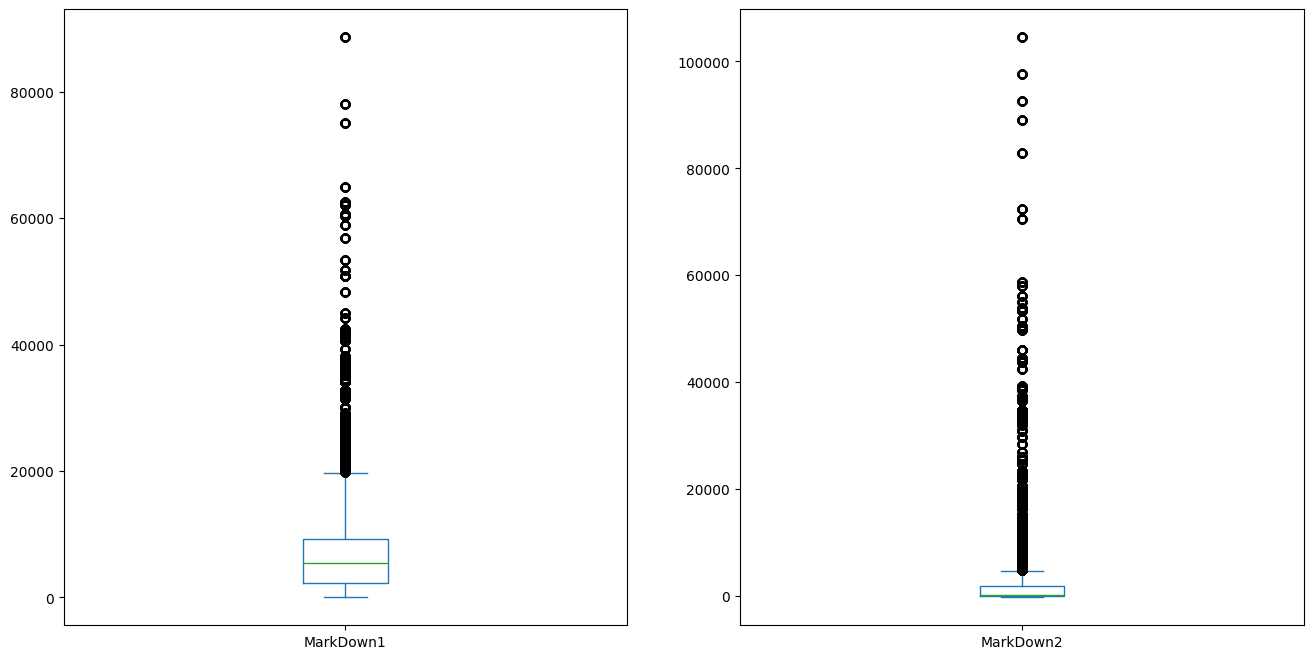

In [36]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
df['MarkDown1'].plot(kind='box')

plt.subplot(1,2,2)
df['MarkDown2'].plot(kind='box')
plt.show()

In [37]:
df=df.drop('Type',axis=1)
df

,Store,Dept,Weekly_Sales,IsHoliday,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
0,1,1,24924.50,False,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2
1,1,1,46039.49,True,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2
2,1,1,41595.55,False,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2
3,1,1,19403.54,False,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2
4,1,1,21827.90,False,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,508.37,False,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9
421566,45,98,628.10,False,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,2012,10
421567,45,98,1061.02,False,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,2012,10
421568,45,98,760.01,False,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,2012,10


In [38]:
df=df.drop('IsHoliday',axis=1)
df

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
0,1,1,24924.50,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2
1,1,1,46039.49,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2
2,1,1,41595.55,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2
3,1,1,19403.54,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2
4,1,1,21827.90,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,508.37,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9
421566,45,98,628.10,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,2012,10
421567,45,98,1061.02,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,2012,10
421568,45,98,760.01,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,2012,10


In [39]:
df.corr()

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
Store,1.000000,0.024004,-0.085195,-0.182881,-0.050097,0.065290,-0.119588,-0.035173,-0.031556,-0.009941,-0.026634,-0.211088,0.208552,0.002997,0.001011
Dept,0.024004,1.000000,0.148032,-0.002966,0.004437,0.003572,-0.002426,0.000290,0.001784,0.004257,0.000109,-0.007477,0.007837,0.003738,0.000904
Weekly_Sales,-0.085195,0.148032,1.000000,0.243828,-0.002312,-0.000120,0.085251,0.024130,0.060385,0.045414,0.090362,-0.020921,-0.025864,-0.010111,0.028409
Size,-0.182881,-0.002966,0.243828,1.000000,-0.058313,0.003361,0.345673,0.108827,0.048913,0.168196,0.304575,-0.003314,-0.068238,-0.004975,-0.001210
Temperature,-0.050097,0.004437,-0.002312,-0.058313,1.000000,0.143859,-0.040594,-0.323927,-0.096880,-0.063947,-0.017544,0.182112,0.096730,0.065814,0.235983
Fuel_Price,0.065290,0.003572,-0.000120,0.003361,0.143859,1.000000,0.061371,-0.220895,-0.102092,-0.044986,-0.128065,-0.164210,-0.033853,0.779633,-0.040876
MarkDown1,-0.119588,-0.002426,0.085251,0.345673,-0.040594,0.061371,1.000000,0.024486,-0.108115,0.819238,0.160257,-0.055558,0.050285,0.141332,-0.176188
MarkDown2,-0.035173,0.000290,0.024130,0.108827,-0.323927,-0.220895,0.024486,1.000000,-0.050108,-0.007768,-0.007440,-0.039534,0.020940,-0.222109,-0.005310
MarkDown3,-0.031556,0.001784,0.060385,0.048913,-0.096880,-0.102092,-0.108115,-0.050108,1.000000,-0.071095,-0.026467,-0.023590,0.012818,-0.319162,0.187871
MarkDown4,-0.009941,0.004257,0.045414,0.168196,-0.063947,-0.044986,0.819238,-0.007768,-0.071095,1.000000,0.107792,-0.049628,0.024963,0.126469,-0.194865


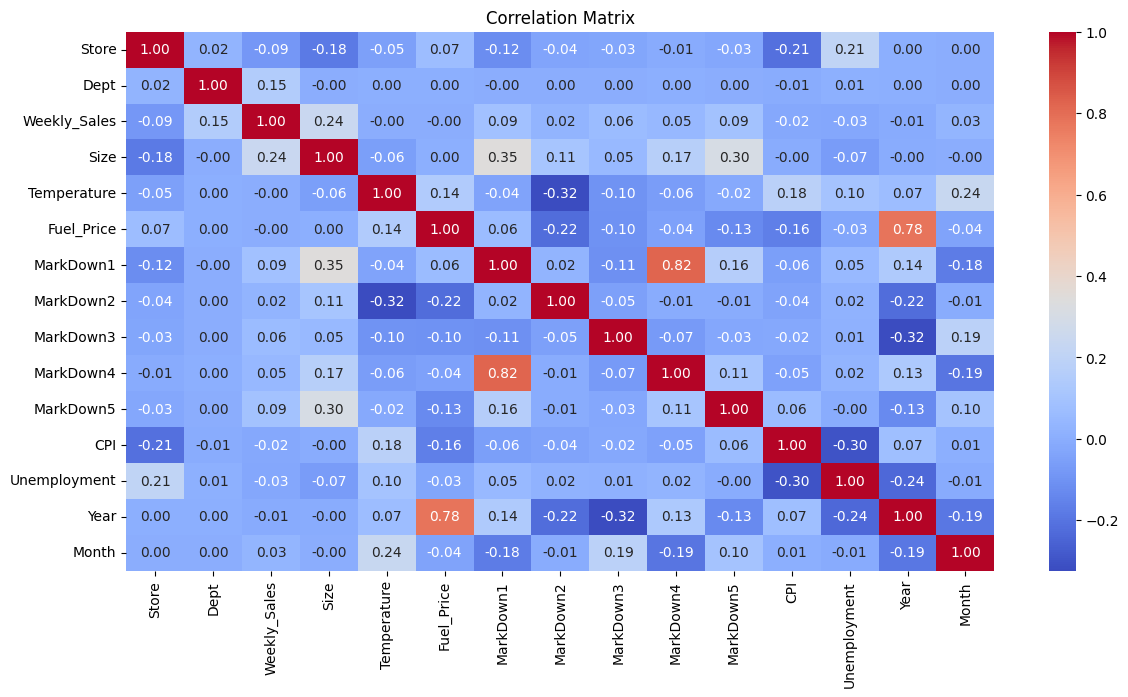

In [40]:
plt.figure(figsize=(14, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Treatment Of Outliers..

In [41]:
q1=df.quantile(0.25)
q1

Store              11.000000
Dept               18.000000
Weekly_Sales     2079.650000
Size            93638.000000
Temperature        46.680000
Fuel_Price          2.933000
MarkDown1        2240.270000
MarkDown2          41.600000
MarkDown3           5.080000
MarkDown4         504.220000
MarkDown5        1878.440000
CPI               132.022667
Unemployment        6.891000
Year             2010.000000
Month               4.000000
Name: 0.25, dtype: float64

In [42]:
q3=df.quantile(0.75)
q3

Store               33.000000
Dept                74.000000
Weekly_Sales     20205.852500
Size            202505.000000
Temperature         74.280000
Fuel_Price           3.738000
MarkDown1         9210.900000
MarkDown2         1926.940000
MarkDown3          103.990000
MarkDown4         3595.040000
MarkDown5         5563.800000
CPI                212.416993
Unemployment         8.572000
Year              2012.000000
Month                9.000000
Name: 0.75, dtype: float64

In [43]:
Iqr=q3-q1
Iqr

Store               22.000000
Dept                56.000000
Weekly_Sales     18126.202500
Size            108867.000000
Temperature         27.600000
Fuel_Price           0.805000
MarkDown1         6970.630000
MarkDown2         1885.340000
MarkDown3           98.910000
MarkDown4         3090.820000
MarkDown5         3685.360000
CPI                 80.394326
Unemployment         1.681000
Year                 2.000000
Month                5.000000
dtype: float64

In [44]:
high_outliers=q3.MarkDown1+1.5*Iqr.MarkDown1
high_outliers

np.float64(19666.845)

In [45]:
low_outliers=q1.MarkDown1-1.5*Iqr.MarkDown1
low_outliers

np.float64(-8215.675)

In [46]:
high_outliers_2=q3.MarkDown2+1.5*Iqr.MarkDown2
high_outliers_2

np.float64(4754.950000000001)

In [47]:
low_outliers_2=q1.MarkDown2-1.5*Iqr.MarkDown2
low_outliers_2

np.float64(-2786.4100000000003)

In [48]:
high_out_ws=q3.Weekly_Sales+1.5*Iqr.Weekly_Sales
high_out_ws

np.float64(47395.15625)

In [49]:
low_out_ws=q1.Weekly_Sales-1.5*Iqr.Weekly_Sales
low_out_ws

np.float64(-25109.653749999998)

---
## Capping
---

In [50]:
import numpy as np
new_df = df.copy()
new_df['MarkDown1']=np.where(new_df['MarkDown1']>high_outliers,
                    high_outliers,
                    np.where(new_df['MarkDown1']<low_outliers,
                    low_outliers,
                    new_df['MarkDown1']
    )
)

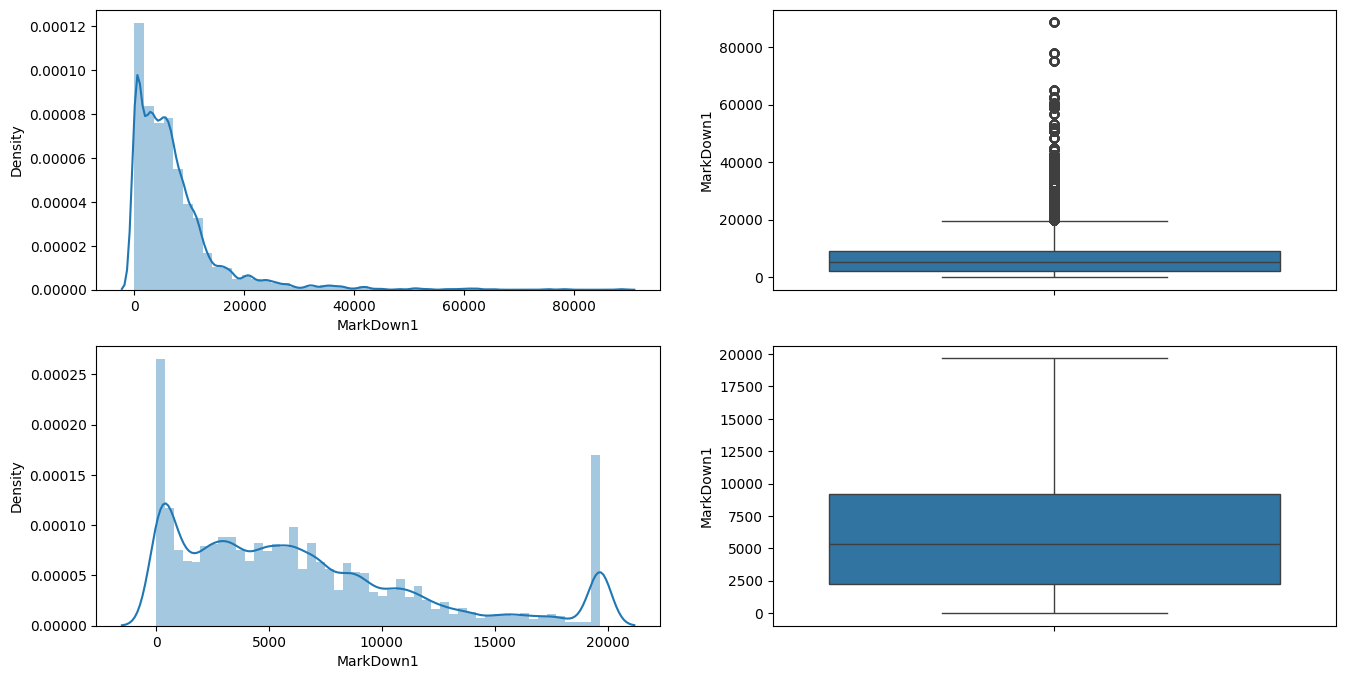

In [51]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['MarkDown1'])

plt.subplot(2,2,2)
sns.boxplot(df['MarkDown1'])

plt.subplot(2,2,3)
sns.distplot(new_df['MarkDown1'])

plt.subplot(2,2,4)
sns.boxplot(new_df['MarkDown1'])

plt.show()

In [52]:
new_df['MarkDown2']=np.where(new_df['MarkDown2']>high_outliers_2,
                    high_outliers_2,
                    np.where(new_df['MarkDown2']<low_outliers_2,
                    low_outliers_2,
                    new_df['MarkDown2']
    )
)

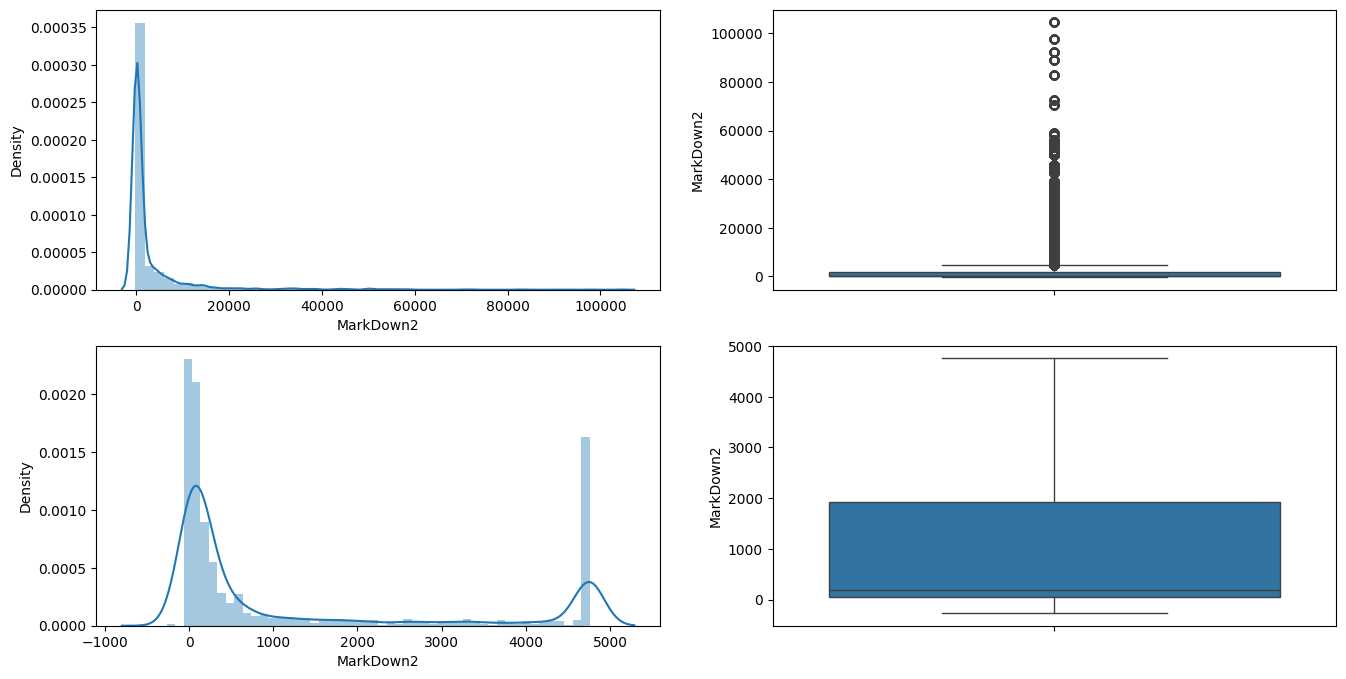

In [53]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['MarkDown2'])

plt.subplot(2,2,2)
sns.boxplot(df['MarkDown2'])

plt.subplot(2,2,3)
sns.distplot(new_df['MarkDown2'])

plt.subplot(2,2,4)
sns.boxplot(new_df['MarkDown2'])

plt.show()

In [54]:
new_df['Weekly_Sales']=np.where(new_df['Weekly_Sales']>high_out_ws,
                    high_out_ws,
                    np.where(new_df['Weekly_Sales']<low_out_ws,
                    low_out_ws,
                    new_df['Weekly_Sales']
    )
)

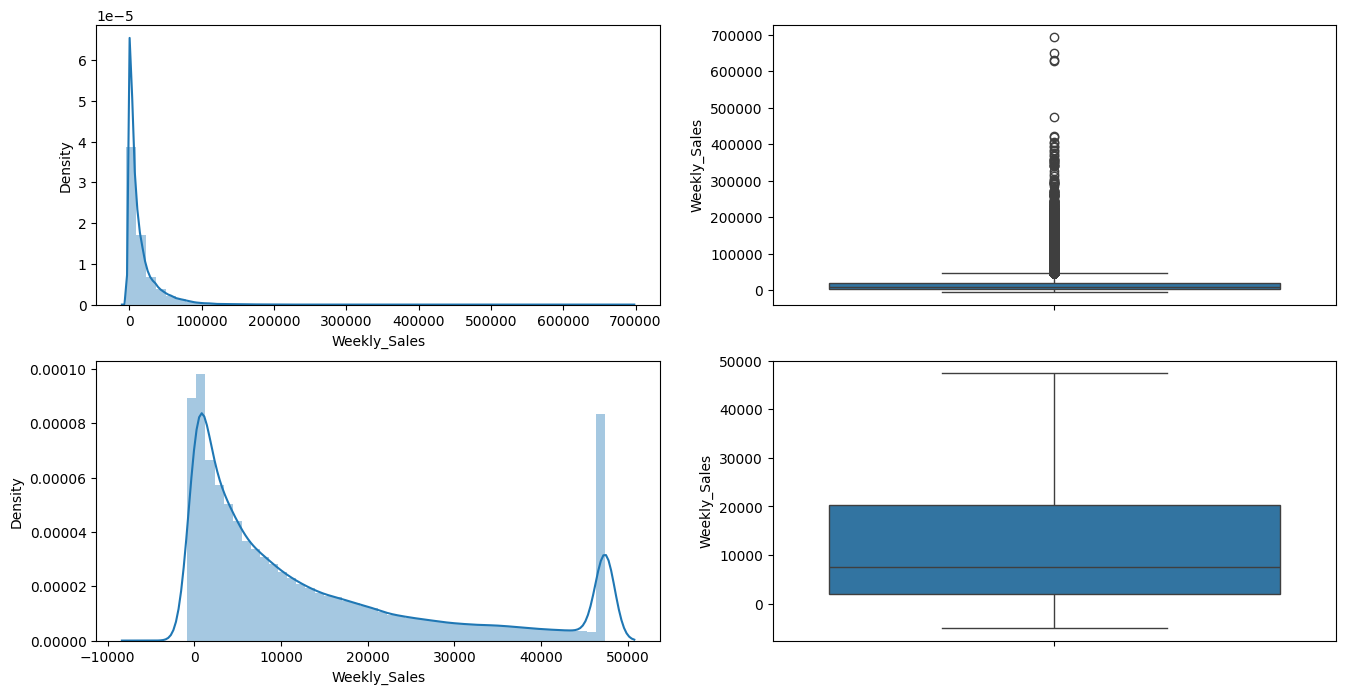

In [55]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['Weekly_Sales'])

plt.subplot(2,2,2)
sns.boxplot(df['Weekly_Sales'])

plt.subplot(2,2,3)
sns.distplot(new_df['Weekly_Sales'])

plt.subplot(2,2,4)
sns.boxplot(new_df['Weekly_Sales'])

plt.show()

***
# Removing Outliers
***

<Axes: ylabel='MarkDown3'>

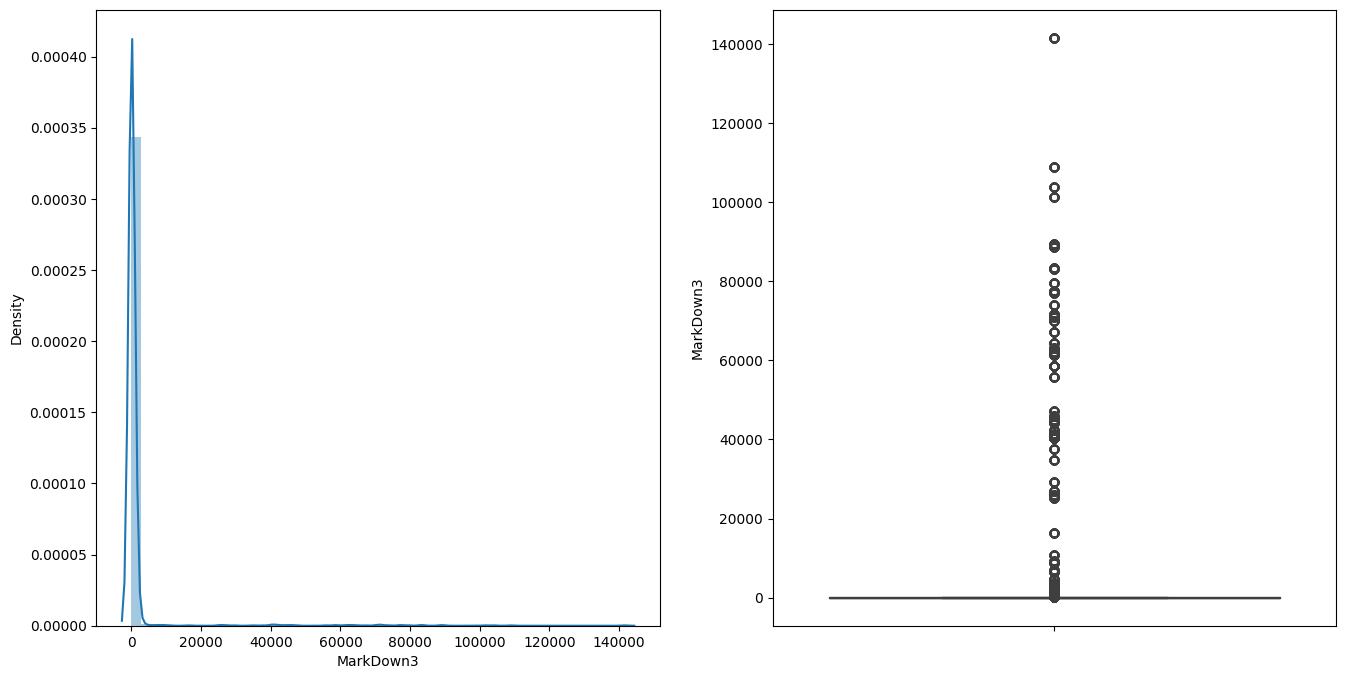

In [56]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
sns.distplot(df['MarkDown3'])

plt.subplot(1,2,2)
sns.boxplot(df['MarkDown3'])

In [57]:
high_out_1=q3.MarkDown3+1.5*Iqr.MarkDown3
high_out_1

np.float64(252.35500000000002)

In [58]:
low_out_1=q1.MarkDown3-1.5*Iqr.MarkDown3
low_out_1

np.float64(-143.285)

In [59]:
index_=np.where(df['MarkDown3']>high_out_1)
index_

(array([    94,     95,     97, ..., 421525, 421526, 421547]),)

In [60]:
Df=df.drop(df.index[index_])
Df

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
0,1,1,24924.50,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2
1,1,1,46039.49,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2
2,1,1,41595.55,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2
3,1,1,19403.54,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2
4,1,1,21827.90,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,508.37,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9
421566,45,98,628.10,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,2012,10
421567,45,98,1061.02,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,2012,10
421568,45,98,760.01,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,2012,10


In [61]:
Df.reset_index()

,index,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
0,0,1,1,24924.50,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2
1,1,1,1,46039.49,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2
2,2,1,1,41595.55,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2
3,3,1,1,19403.54,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2
4,4,1,1,21827.90,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402907,421565,45,98,508.37,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,2012,9
402908,421566,45,98,628.10,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,2012,10
402909,421567,45,98,1061.02,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,2012,10
402910,421568,45,98,760.01,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,2012,10


<Axes: ylabel='MarkDown3'>

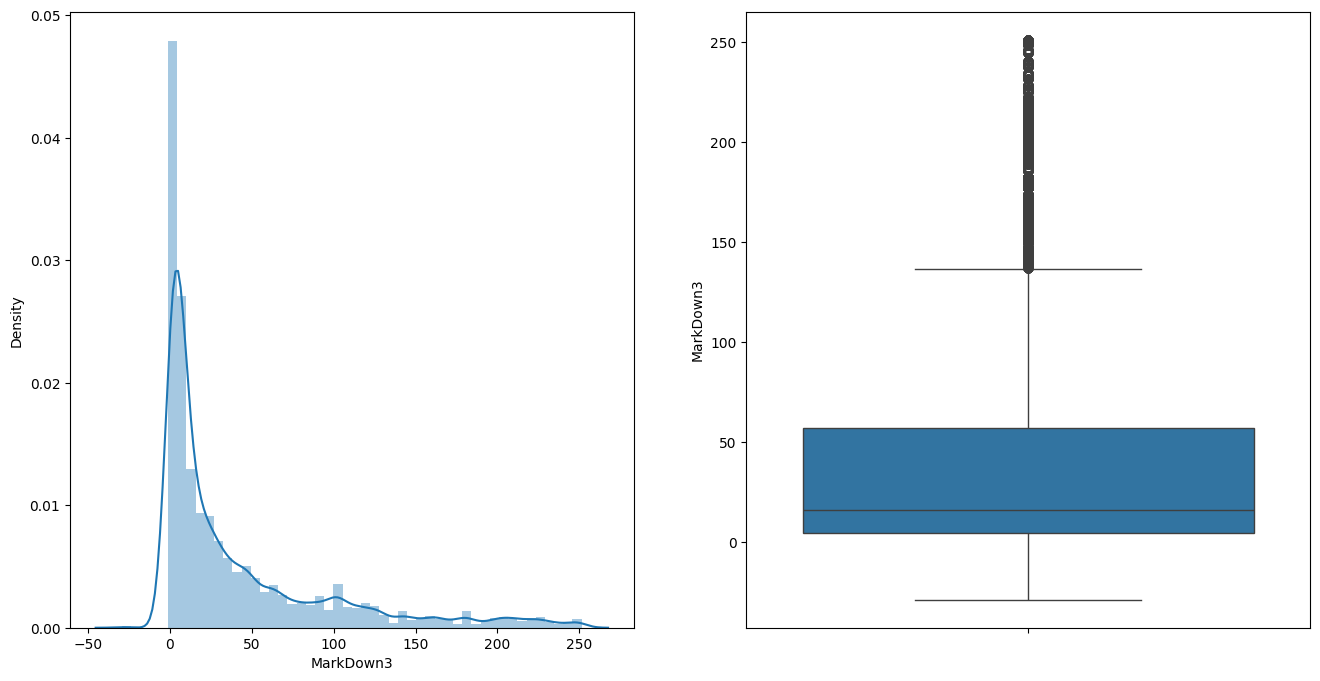

In [62]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
sns.distplot(Df['MarkDown3'])

plt.subplot(1,2,2)
sns.boxplot(Df['MarkDown3'])

---
### do it again by capping
---

In [63]:
new_df['MarkDown3']=np.where(new_df['MarkDown3']>high_out_1,
                    high_out_1,
                    np.where(new_df['MarkDown3']<low_out_1,
                    low_out_1,
                    new_df['MarkDown3']
    )
)

In [64]:
high_out_2=q3.MarkDown4+1.5*Iqr.MarkDown4
high_out_2

np.float64(8231.27)

In [65]:
low_out_2=q3.MarkDown4-1.5*Iqr.MarkDown4
low_out_2

np.float64(-1041.1899999999996)

In [66]:
new_df['MarkDown4']=np.where(new_df['MarkDown4']>high_out_2,
                    high_out_2,
                    np.where(new_df['MarkDown4']<low_out_2,
                    low_out_2,
                    new_df['MarkDown4']
    )
)

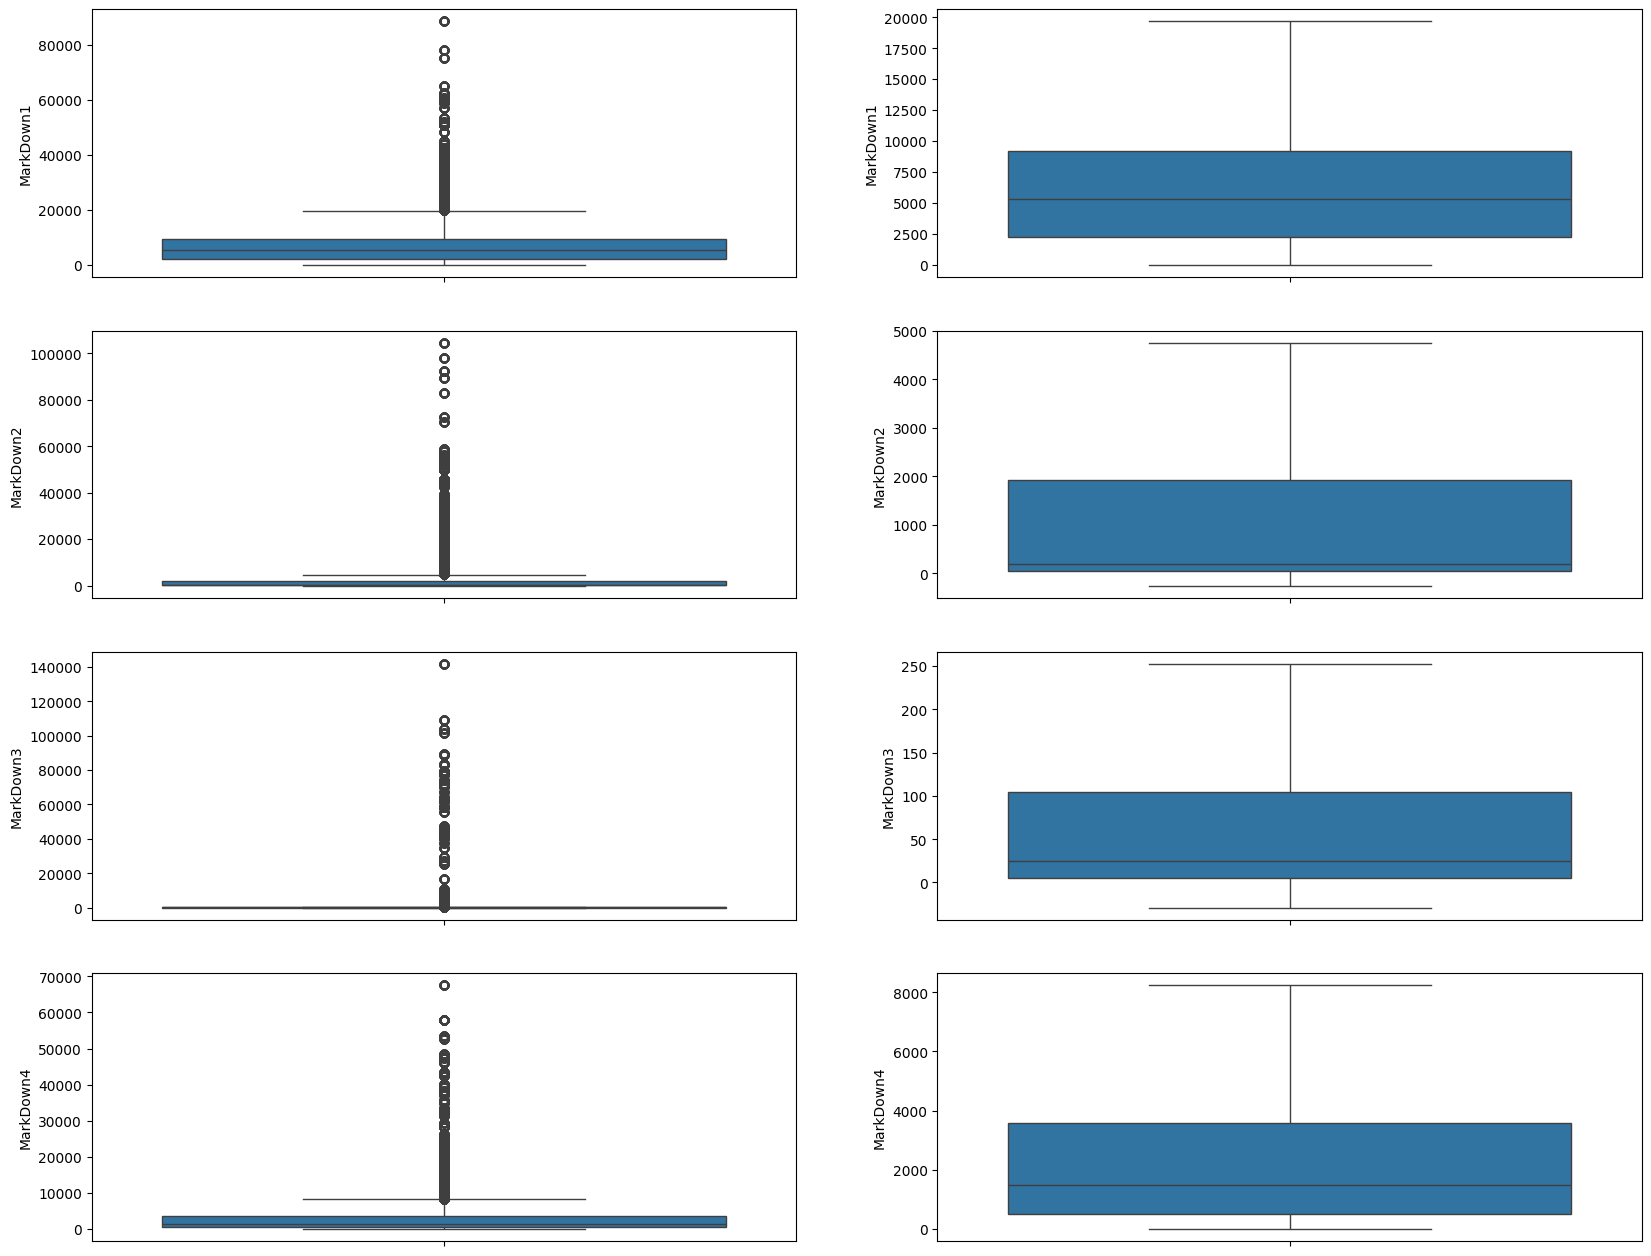

In [67]:
plt.figure(figsize=(20,16))
plt.subplot(4,2,1)
sns.boxplot(df['MarkDown1'])

plt.subplot(4,2,2)
sns.boxplot(new_df['MarkDown1'])

plt.subplot(4,2,3)
sns.boxplot(df['MarkDown2'])

plt.subplot(4,2,4)
sns.boxplot(new_df['MarkDown2'])

plt.subplot(4,2,5)
sns.boxplot(df['MarkDown3'])

plt.subplot(4,2,6)
sns.boxplot(new_df['MarkDown3'])

plt.subplot(4,2,7)
sns.boxplot(df['MarkDown4'])

plt.subplot(4,2,8)
sns.boxplot(new_df['MarkDown4'])


plt.show()

<Axes: ylabel='MarkDown5'>

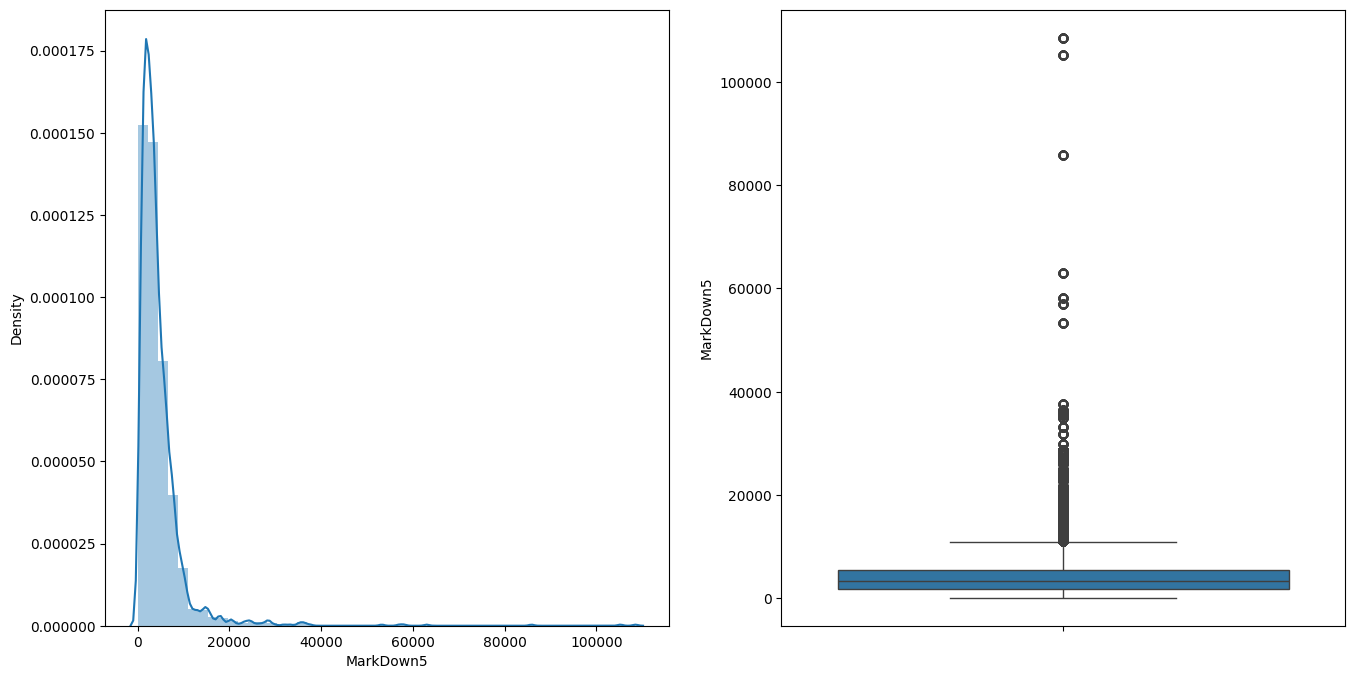

In [68]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
sns.distplot(df['MarkDown5'])

plt.subplot(1,2,2)
sns.boxplot(df['MarkDown5'])

In [69]:
high_out=q3.MarkDown5+1.5*Iqr.MarkDown5
high_out

np.float64(11091.84)

In [70]:
low_out=q1.MarkDown5-1.5*Iqr.MarkDown5
low_out

np.float64(-3649.6)

In [71]:
new_df['MarkDown5']=np.where(new_df['MarkDown5']>high_out,
                    high_out,
                    np.where(new_df['MarkDown5']<low_out,
                    low_out,
                    new_df['MarkDown5']
    )
)

<Axes: ylabel='Unemployment'>

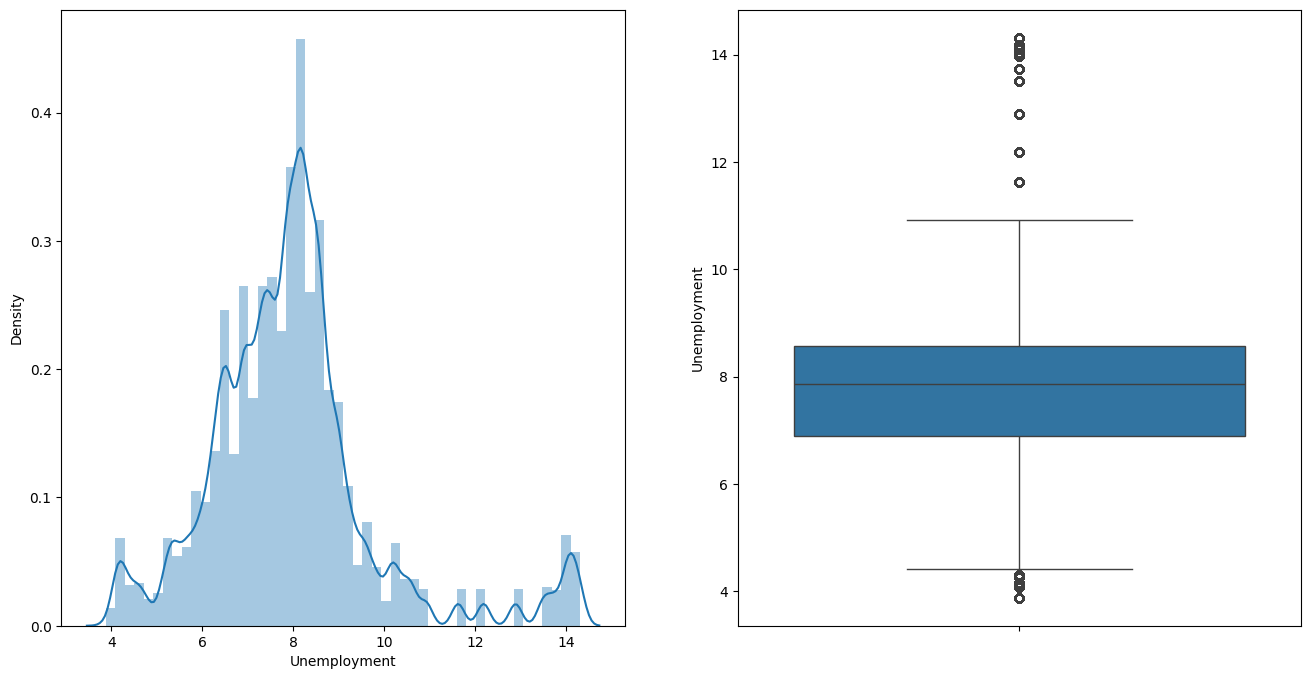

In [72]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
sns.distplot(df['Unemployment'])

plt.subplot(1,2,2)
sns.boxplot(df['Unemployment'])

In [73]:
high_outi=q3.Unemployment+1.5*Iqr.Unemployment
high_outi

np.float64(11.093499999999999)

In [74]:
low_outi=q1.Unemployment-1.5*Iqr.Unemployment
low_outi

np.float64(4.369500000000001)

In [75]:
new_df['Unemployment']=np.where(new_df['Unemployment']>high_outi,
                    high_outi,
                    np.where(new_df['Unemployment']<low_outi,
                    low_outi,
                    new_df['Unemployment']
    )
)

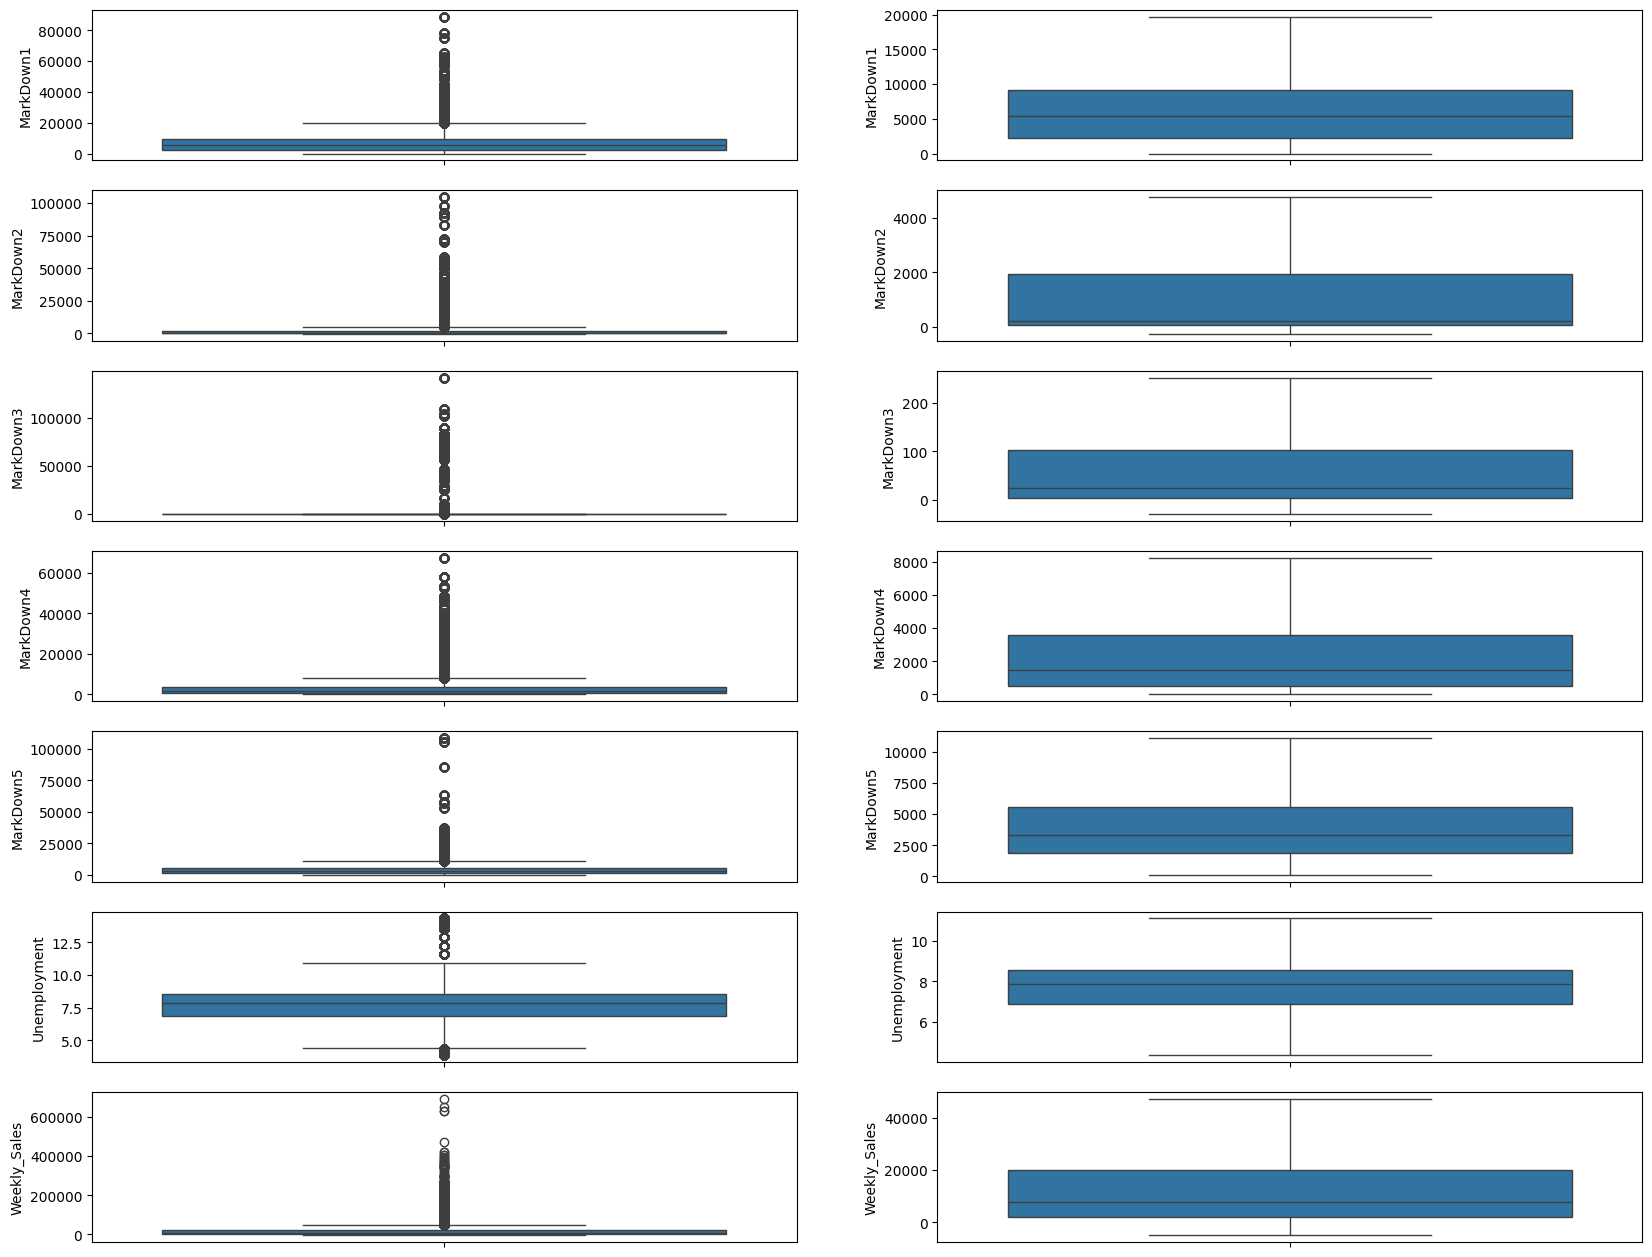

In [76]:
plt.figure(figsize=(20,16))
plt.subplot(7,2,1)
sns.boxplot(df['MarkDown1'])

plt.subplot(7,2,2)
sns.boxplot(new_df['MarkDown1'])

plt.subplot(7,2,3)
sns.boxplot(df['MarkDown2'])

plt.subplot(7,2,4)
sns.boxplot(new_df['MarkDown2'])

plt.subplot(7,2,5)
sns.boxplot(df['MarkDown3'])

plt.subplot(7,2,6)
sns.boxplot(new_df['MarkDown3'])

plt.subplot(7,2,7)
sns.boxplot(df['MarkDown4'])

plt.subplot(7,2,8)
sns.boxplot(new_df['MarkDown4'])

plt.subplot(7,2,9)
sns.boxplot(df['MarkDown5'])

plt.subplot(7,2,10)
sns.boxplot(new_df['MarkDown5'])

plt.subplot(7,2,11)
sns.boxplot(df['Unemployment'])

plt.subplot(7,2,12)
sns.boxplot(new_df['Unemployment'])

plt.subplot(7,2,13)
sns.boxplot(df['Weekly_Sales'])

plt.subplot(7,2,14)
sns.boxplot(new_df['Weekly_Sales'])


plt.show()

___
## Scatter ploting
___

In [77]:
new_df.head()

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month
0,1,1,24924.50,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2
1,1,1,46039.49,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2
2,1,1,41595.55,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2
3,1,1,19403.54,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2
4,1,1,21827.90,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3


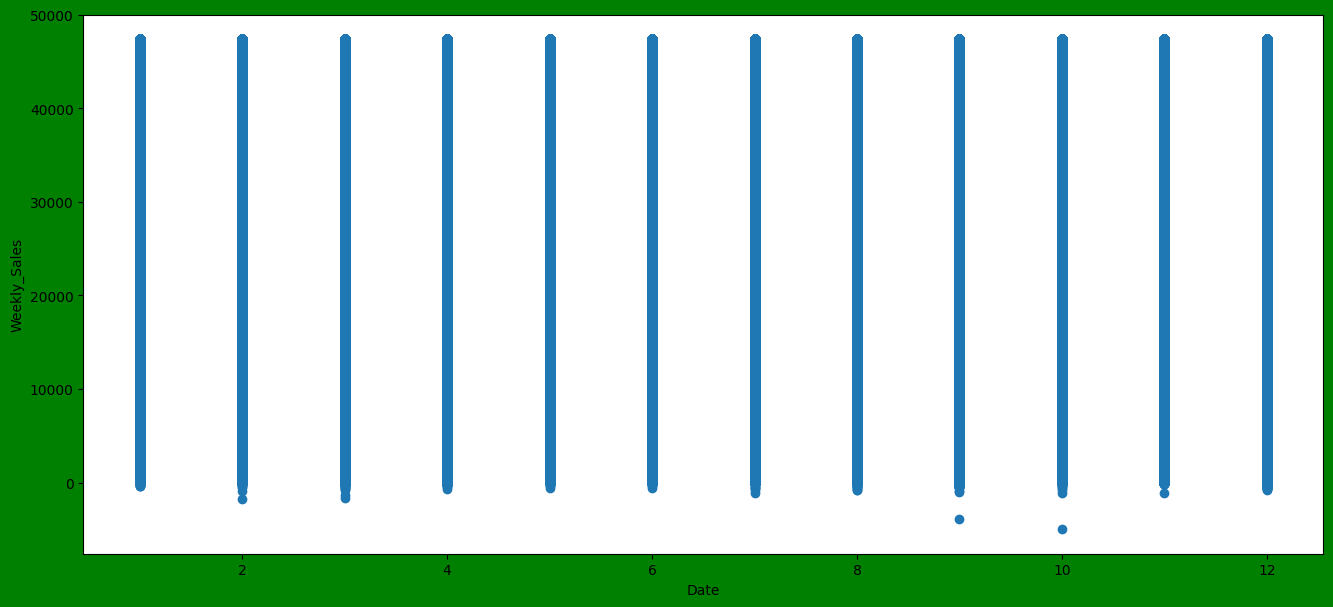

In [78]:
plt.figure(figsize=(16,7),facecolor="green")
plt.scatter(x=new_df['Month'],y=new_df['Weekly_Sales'])
plt.xlabel('Date')
plt.ylabel('Weekly_Sales')
plt.show()

---

## Univariate Analysis
---

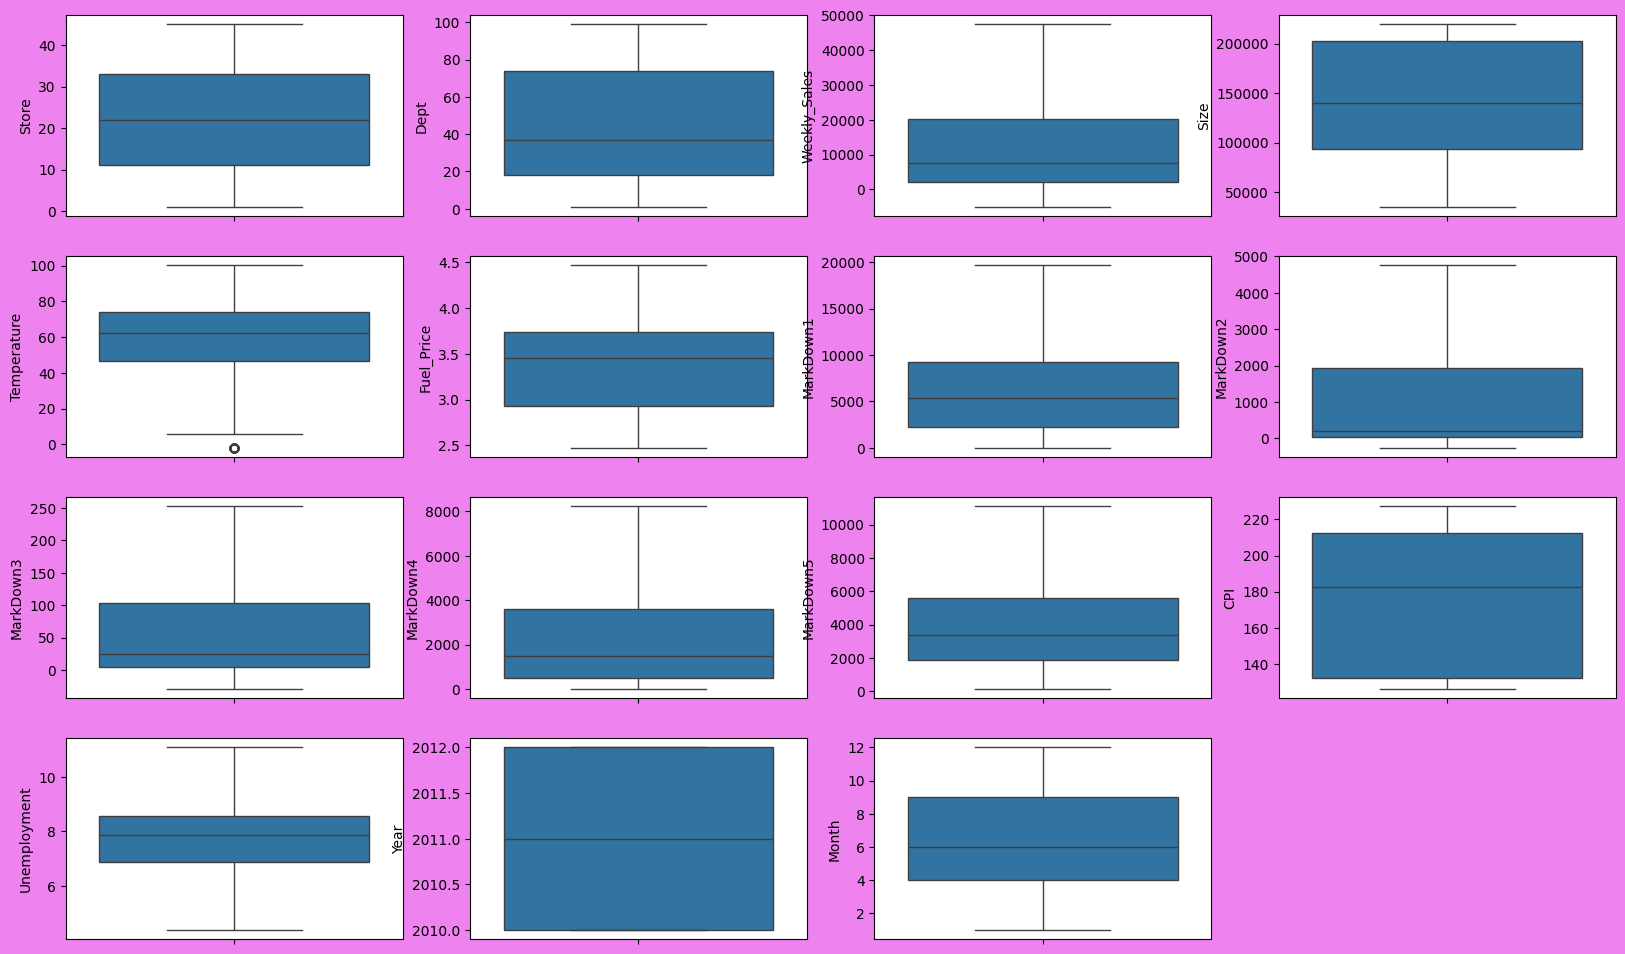

In [79]:
plt.figure(figsize=(20, 12),facecolor="violet")
for i, column in enumerate(new_df.select_dtypes(include='number'),1):
    plt.subplot(4,4,i)
    sns.boxplot(new_df[column])

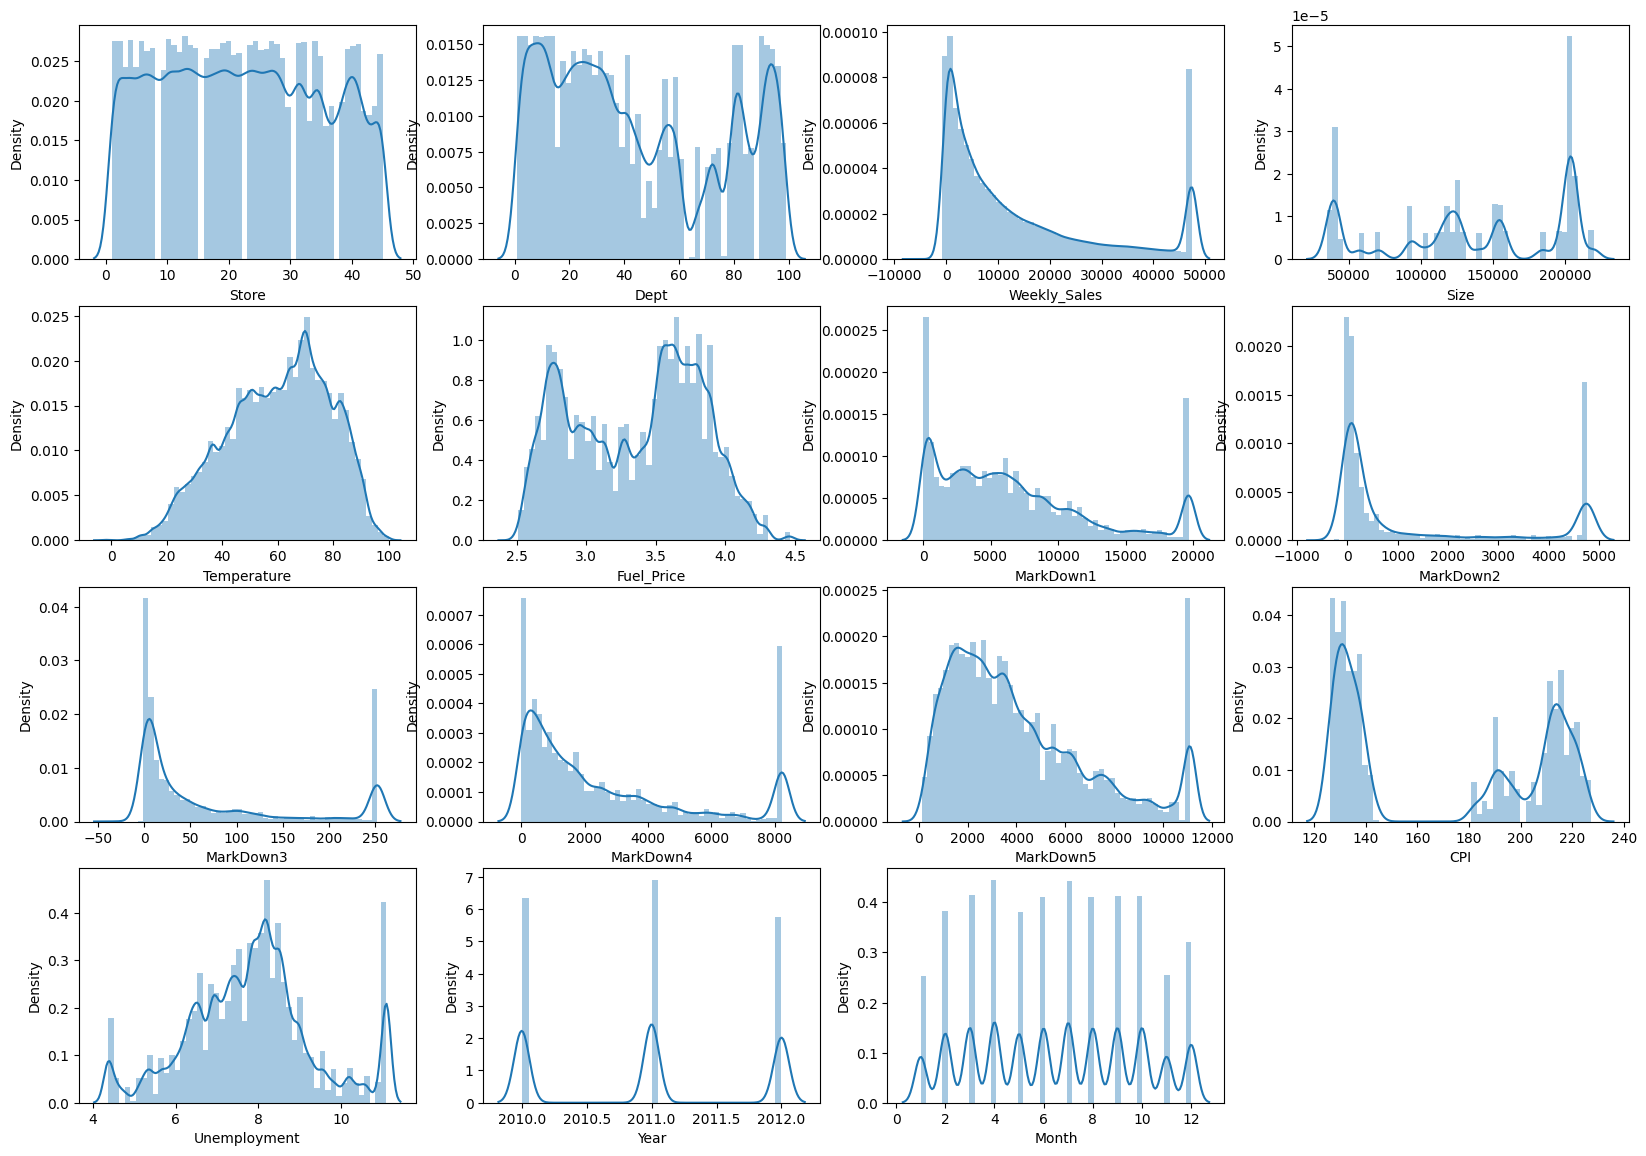

In [80]:
plt.figure(figsize=(20, 14))
for i, column in enumerate(new_df.select_dtypes(include='number'),1):
    plt.subplot(4,4,i)
    sns.distplot(new_df[column])

In [81]:
for i in new_df.select_dtypes(include='number'):
    skewness=new_df[i].skew()
    print("The skewness of",i,"is",skewness)

The skewness of Store is 0.07776250174537733
The skewness of Dept is 0.3582231934713366
The skewness of Weekly_Sales is 1.1682384133485475
The skewness of Size is -0.3258497664635348
The skewness of Temperature is -0.3214041519699762
The skewness of Fuel_Price is -0.10490149562840598
The skewness of MarkDown1 is 0.9735322105579078
The skewness of MarkDown2 is 1.2014917881854539
The skewness of MarkDown3 is 1.2007760771714502
The skewness of MarkDown4 is 1.1969709810692746
The skewness of MarkDown5 is 0.9778952750155905
The skewness of CPI is 0.08521928473260011
The skewness of Unemployment is 0.13980023921567286
The skewness of Year is 0.05623644391430117
The skewness of Month is 0.04078624154148521
